In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/comparisons')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/comparisons


In [5]:
# Load JSONL results
toy_1d_path =    Path("../experiment_results/toy_1d_scan.jsonl")
poly_path   =    Path("../experiment_results/polynomial_scan.jsonl")
mnist_path  =    Path("../experiment_results/mnist_scan_labelRegression.jsonl")

def get_df(path):
    records = []
    with open(path) as f:
        for line in f:
            l = json.loads(line)
            if l['optimizer'] == 'SVD':
                records.append(l)

    df = pd.DataFrame(records)
    return df

df_1d = get_df(toy_1d_path)
df_poly = get_df(poly_path)
df_mnist = get_df(mnist_path)

In [6]:
bs_1d = df_1d['batch_size'].unique()[0]
bs_poly = df_poly['batch_size'].unique()[0]
bs_mnist = df_mnist['batch_size'].unique()[0]

# Custom plots

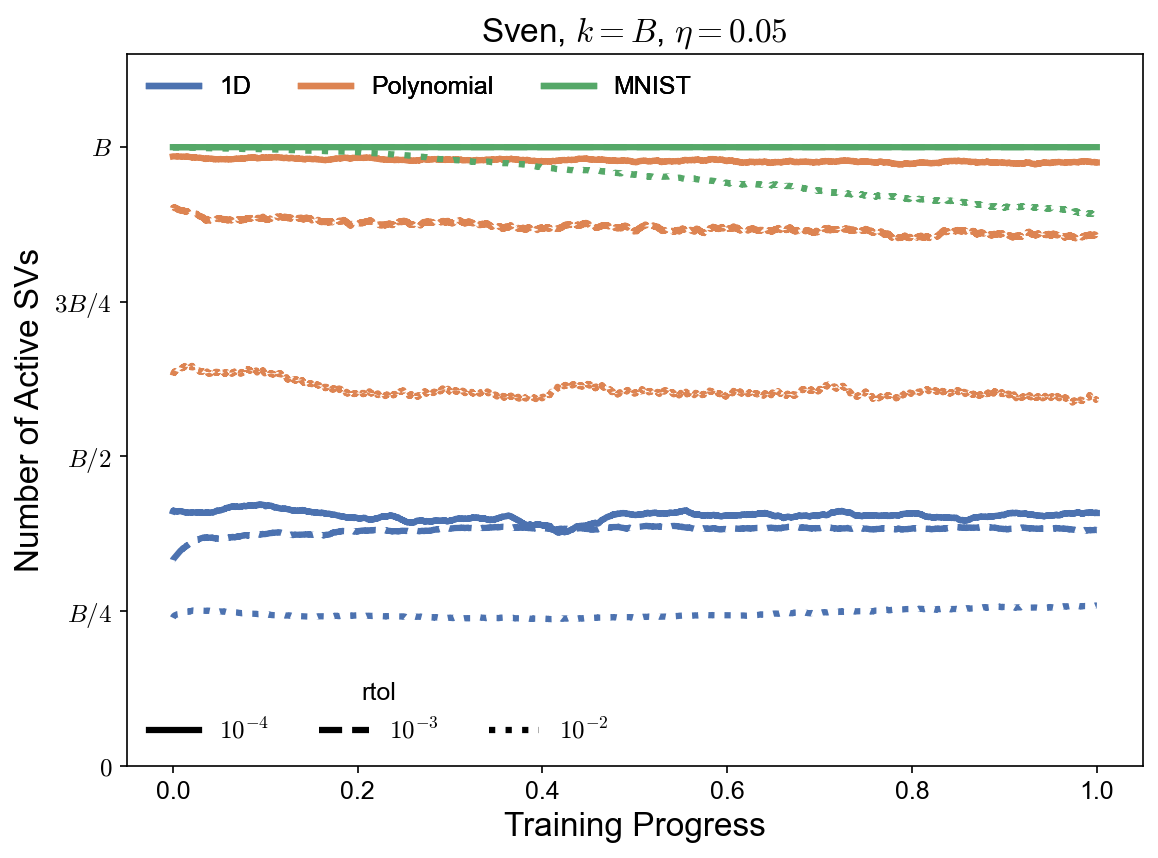

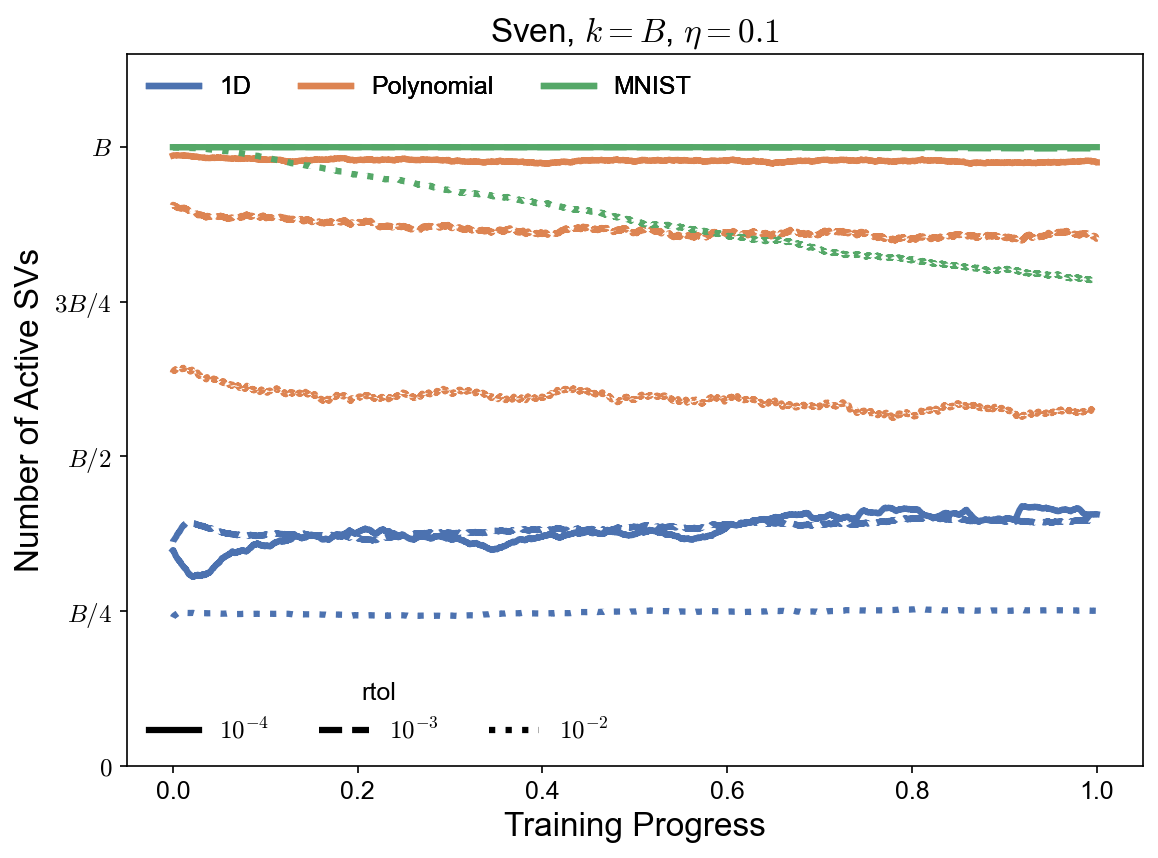

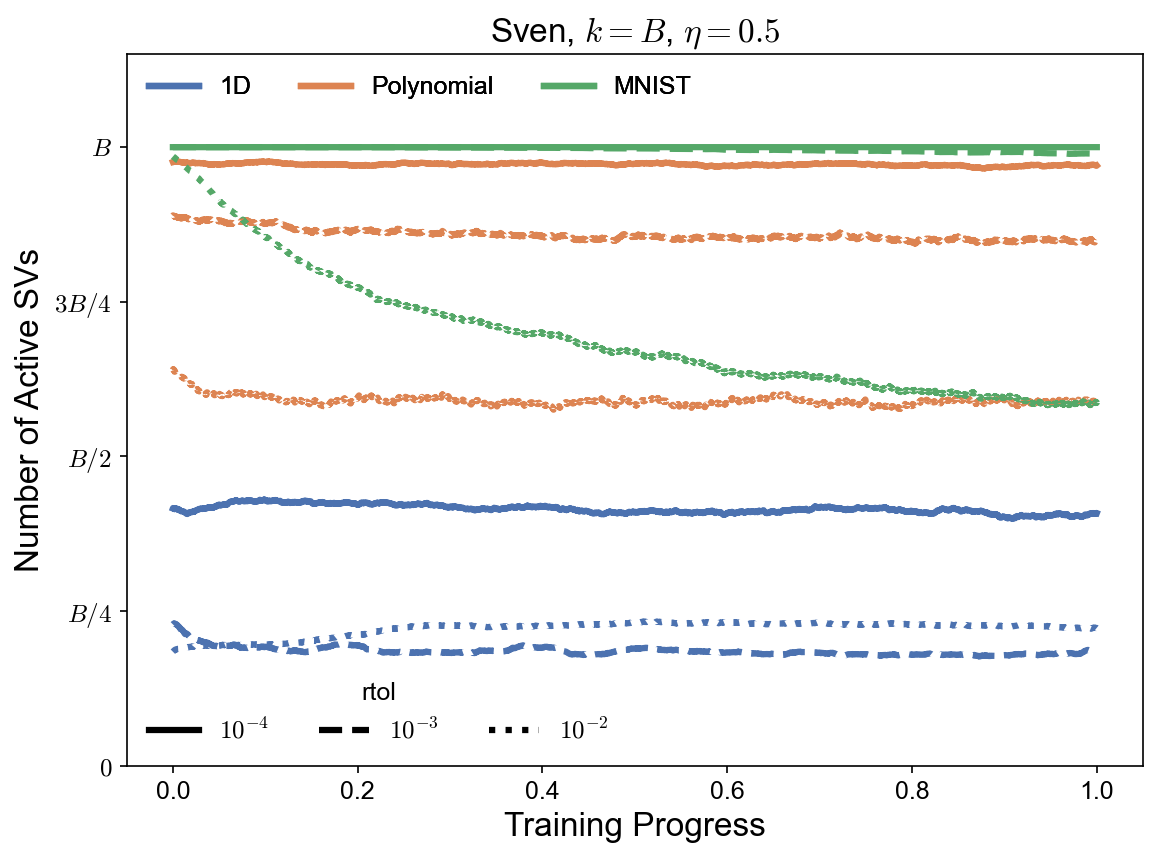

In [49]:
RTOLS = [1e-4, 1e-3, 1e-2]
LRS = [0.05, 0.1, 0.5]
def get_filter(N):
    return np.ones(N)/N
colors = sns.color_palette("deep")
for lr in LRS:
    fig, ax = plt.subplots(figsize=(8, 6))
    linestyles = ['-', '--', ':']
    for i,rtol in enumerate(RTOLS):
        df_1d_sel = df_1d[(df_1d['rtol'] == rtol) & (df_1d['lr'] == lr) & (df_1d['k'] == bs_1d)].iloc[0]
        df_poly_sel = df_poly[(df_poly['rtol'] == rtol) & (df_poly['lr'] == lr) & (df_poly['k'] == bs_poly)].iloc[0]
        df_mnist_sel = df_mnist[(df_mnist['rtol'] == rtol) & (df_mnist['lr'] == lr) & (df_mnist['k'] == bs_mnist)].iloc[0]

        n_epoch_1d = len(df_1d_sel['losses']['train'])
        n_epoch_poly = len(df_poly_sel['losses']['train'])
        n_epoch_mnist = len(df_mnist_sel['losses']['train'])

        b_frac_smooth = 1.0

        svs_1d = np.array(df_1d_sel['svd_info']['num_nonzero_svs'])
        b_per_ep_1d = len(svs_1d) // n_epoch_1d
        svs_1d = np.convolve(svs_1d, get_filter(int(b_per_ep_1d * b_frac_smooth)), mode='valid')
        x_1d = np.linspace(0,1,len(svs_1d))
        
        svs_poly = np.array(df_poly_sel['svd_info']['num_nonzero_svs'])
        b_per_ep_poly = len(svs_poly) // n_epoch_poly
        svs_poly = np.convolve(svs_poly, get_filter(int(b_per_ep_poly * b_frac_smooth)), mode='valid')
        x_poly = np.linspace(0,1,len(svs_poly))

        svs_mnist = np.array(df_mnist_sel['svd_info']['num_nonzero_svs'])
        b_per_ep_mnist = len(svs_mnist) // n_epoch_mnist
        svs_mnist = np.convolve(svs_mnist, get_filter(int(b_per_ep_mnist * b_frac_smooth)), mode='valid')
        x_mnist = np.linspace(0,1,len(svs_mnist))

        ax.plot(x_1d, svs_1d/bs_1d, color=colors[0], linestyle=linestyles[i],linewidth=3)
        ax.plot(x_poly, svs_poly/bs_poly, color=colors[1], linestyle=linestyles[i],linewidth=3)
        ax.plot(x_mnist, svs_mnist/bs_mnist, color=colors[2], linestyle=linestyles[i],linewidth=3)

        ax.set_ylim(0,1.15)
        ax.set_yticks([0,0.25,0.5,0.75,1],labels=[f"$0$","$B/4$","$B/2$","$3B/4$","$B$"])
        ax.set_ylabel("Number of Active SVs")
        ax.set_xlabel("Training Progress")

        ax.set_title(f"Sven, $k = B$, $\eta = {lr}$")

        legend_entries = [
            Line2D([],[],color=colors[0], label="1D", lw=3),
            Line2D([],[],color=colors[1], label="Polynomial", lw=3),
            Line2D([],[],color=colors[2], label="MNIST", lw=3)
        ]
        leg1 = ax.legend(handles=legend_entries, loc='upper left', frameon=False,ncol=3)
        rtol_entries = [
            Line2D([],[],color='k', label=f"${lr_labels[rtol]}$", lw=3, linestyle=linestyles[i]) for i,rtol in enumerate(RTOLS)
        ]
        leg2 = ax.legend(handles=rtol_entries, loc='lower left', frameon=False, title='rtol', title_fontsize=12,ncol=3)
        ax.add_artist(leg1)

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"svs_comparison_lr{lr}.pdf")

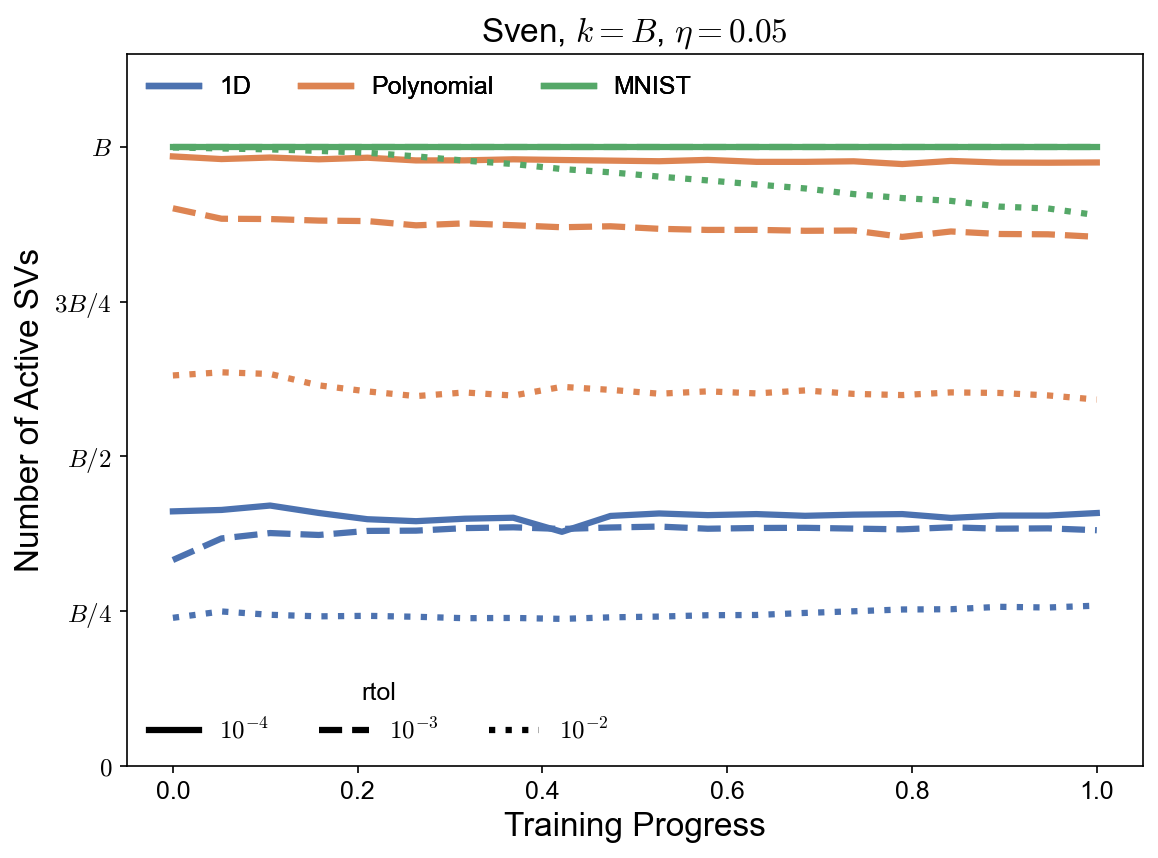

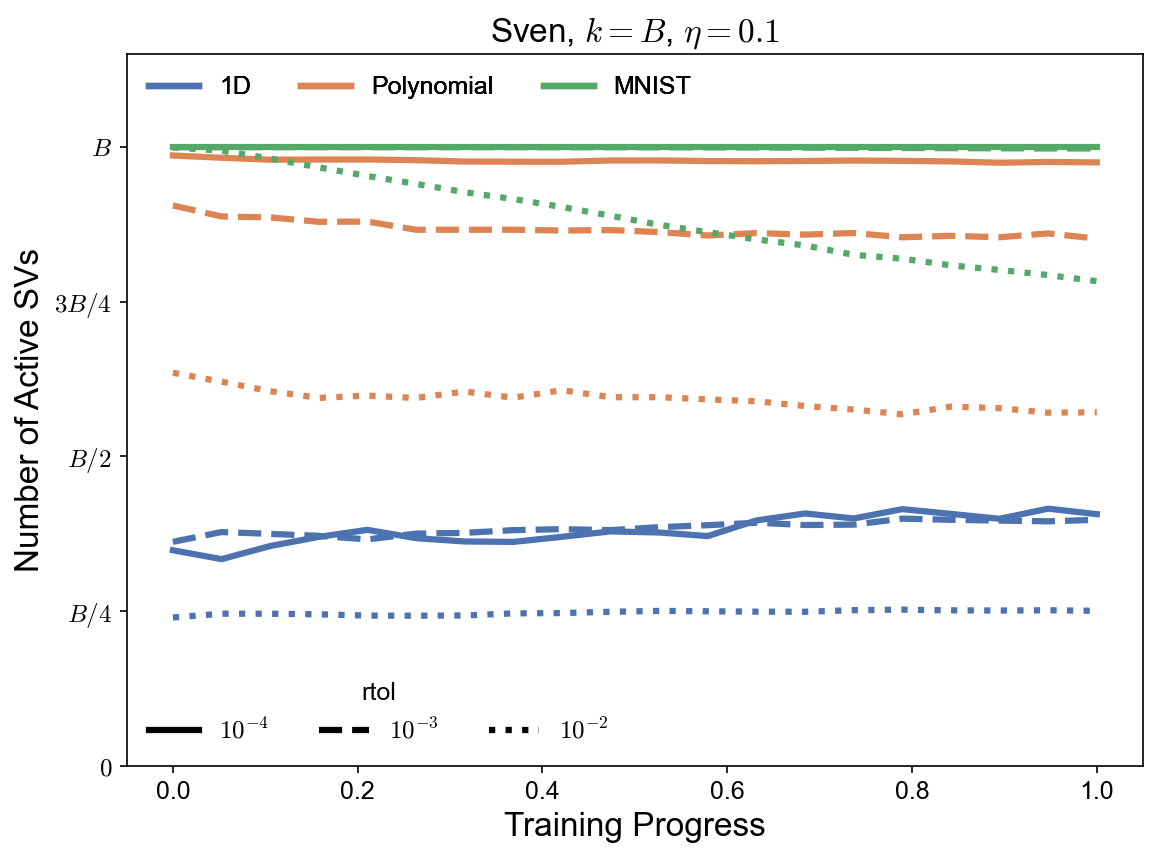

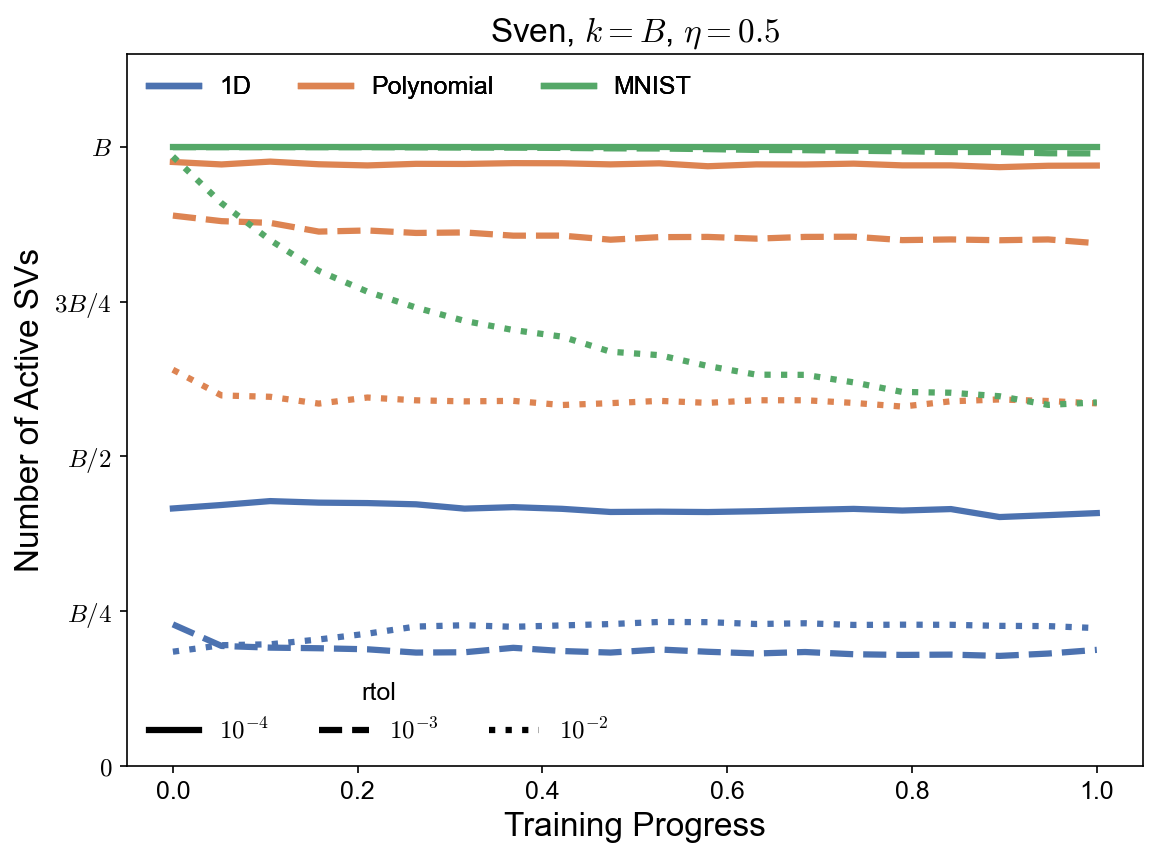

In [51]:
RTOLS = [1e-4, 1e-3, 1e-2]
LRS = [0.05, 0.1, 0.5]
colors = sns.color_palette("deep")
for lr in LRS:
    fig, ax = plt.subplots(figsize=(8, 6))
    linestyles = ['-', '--', ':']
    for i,rtol in enumerate(RTOLS):
        df_1d_sel = df_1d[(df_1d['rtol'] == rtol) & (df_1d['lr'] == lr) & (df_1d['k'] == bs_1d)].iloc[0]
        df_poly_sel = df_poly[(df_poly['rtol'] == rtol) & (df_poly['lr'] == lr) & (df_poly['k'] == bs_poly)].iloc[0]
        df_mnist_sel = df_mnist[(df_mnist['rtol'] == rtol) & (df_mnist['lr'] == lr) & (df_mnist['k'] == bs_mnist)].iloc[0]

        n_epoch_1d = len(df_1d_sel['losses']['train'])
        n_epoch_poly = len(df_poly_sel['losses']['train'])
        n_epoch_mnist = len(df_mnist_sel['losses']['train'])

        svs_1d = np.array(df_1d_sel['svd_info']['num_nonzero_svs']).reshape(n_epoch_1d, -1).mean(axis=1)
        x_1d = np.linspace(0,1,len(svs_1d))
        
        svs_poly = np.array(df_poly_sel['svd_info']['num_nonzero_svs']).reshape(n_epoch_poly, -1).mean(axis=1)
        x_poly = np.linspace(0,1,len(svs_poly))

        svs_mnist = np.array(df_mnist_sel['svd_info']['num_nonzero_svs']).reshape(n_epoch_mnist, -1).mean(axis=1)
        x_mnist = np.linspace(0,1,len(svs_mnist))

        ax.plot(x_1d, svs_1d/bs_1d, color=colors[0], linestyle=linestyles[i],linewidth=3)
        ax.plot(x_poly, svs_poly/bs_poly, color=colors[1], linestyle=linestyles[i],linewidth=3)
        ax.plot(x_mnist, svs_mnist/bs_mnist, color=colors[2], linestyle=linestyles[i],linewidth=3)

        ax.set_ylim(0,1.15)
        ax.set_yticks([0,0.25,0.5,0.75,1],labels=[f"$0$","$B/4$","$B/2$","$3B/4$","$B$"])
        ax.set_ylabel("Number of Active SVs")
        ax.set_xlabel("Training Progress")

        ax.set_title(f"Sven, $k = B$, $\eta = {lr}$")

        legend_entries = [
            Line2D([],[],color=colors[0], label="1D", lw=3),
            Line2D([],[],color=colors[1], label="Polynomial", lw=3),
            Line2D([],[],color=colors[2], label="MNIST", lw=3)
        ]
        leg1 = ax.legend(handles=legend_entries, loc='upper left', frameon=False,ncol=3)
        rtol_entries = [
            Line2D([],[],color='k', label=f"${lr_labels[rtol]}$", lw=3, linestyle=linestyles[i]) for i,rtol in enumerate(RTOLS)
        ]
        leg2 = ax.legend(handles=rtol_entries, loc='lower left', frameon=False, title='rtol', title_fontsize=12,ncol=3)
        ax.add_artist(leg1)

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"svs_comparison_lr{lr}_epochAveraged.pdf")

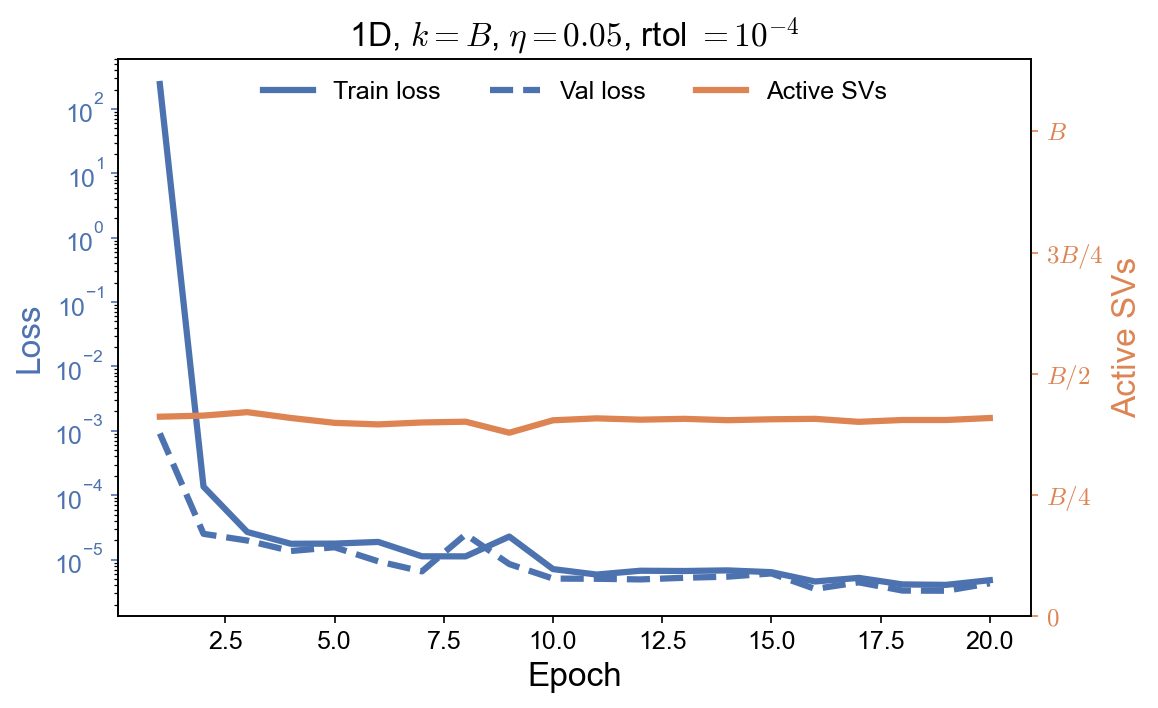

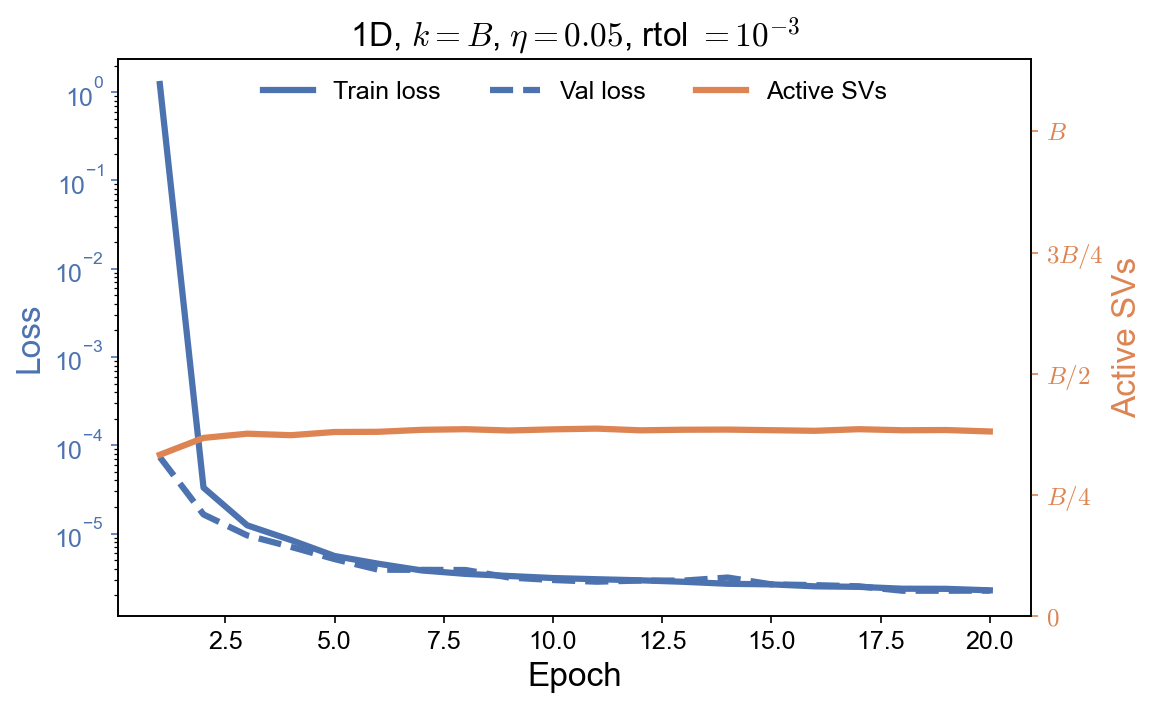

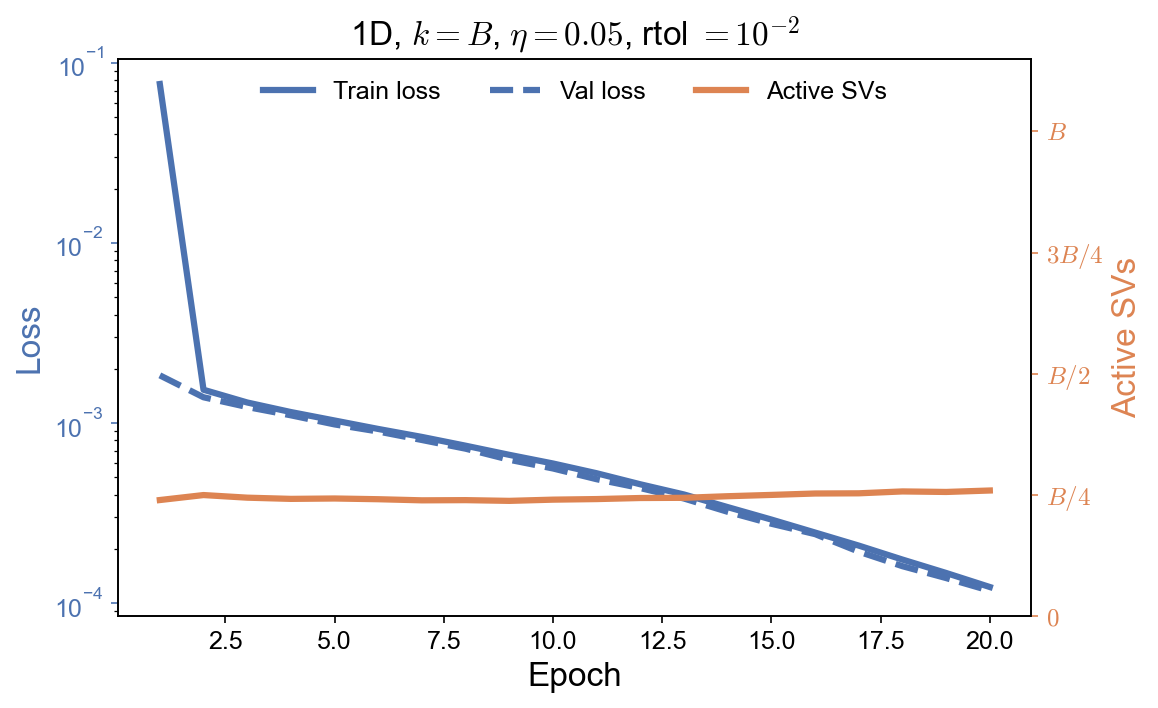

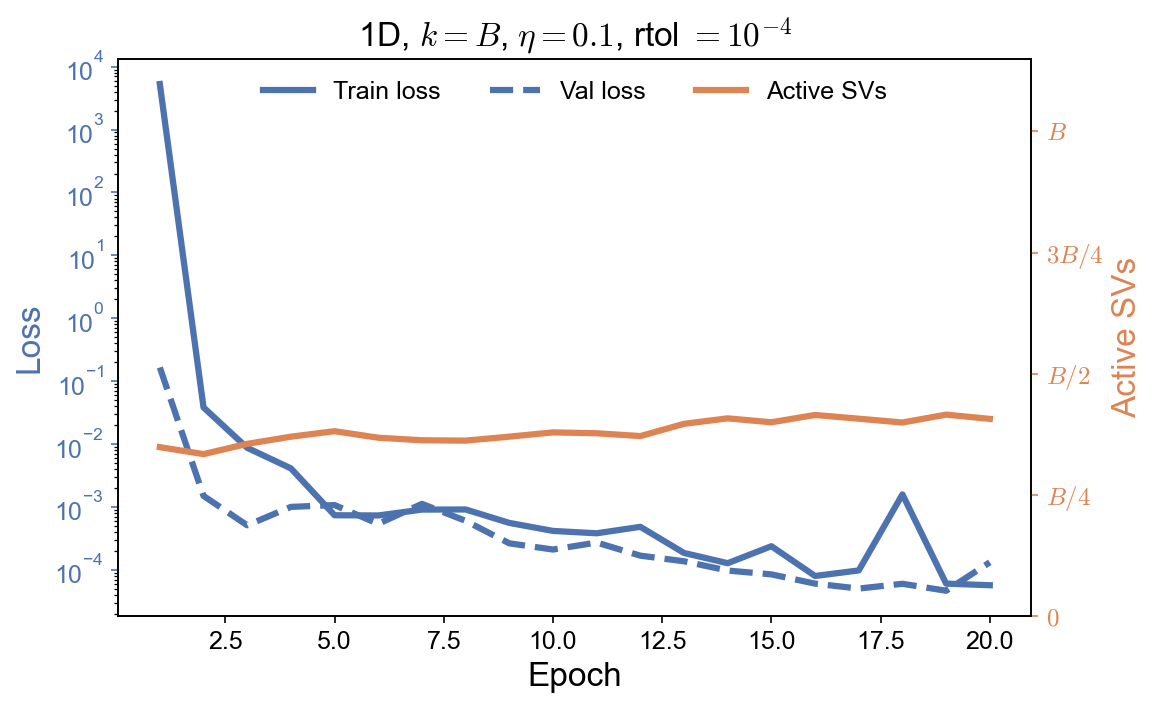

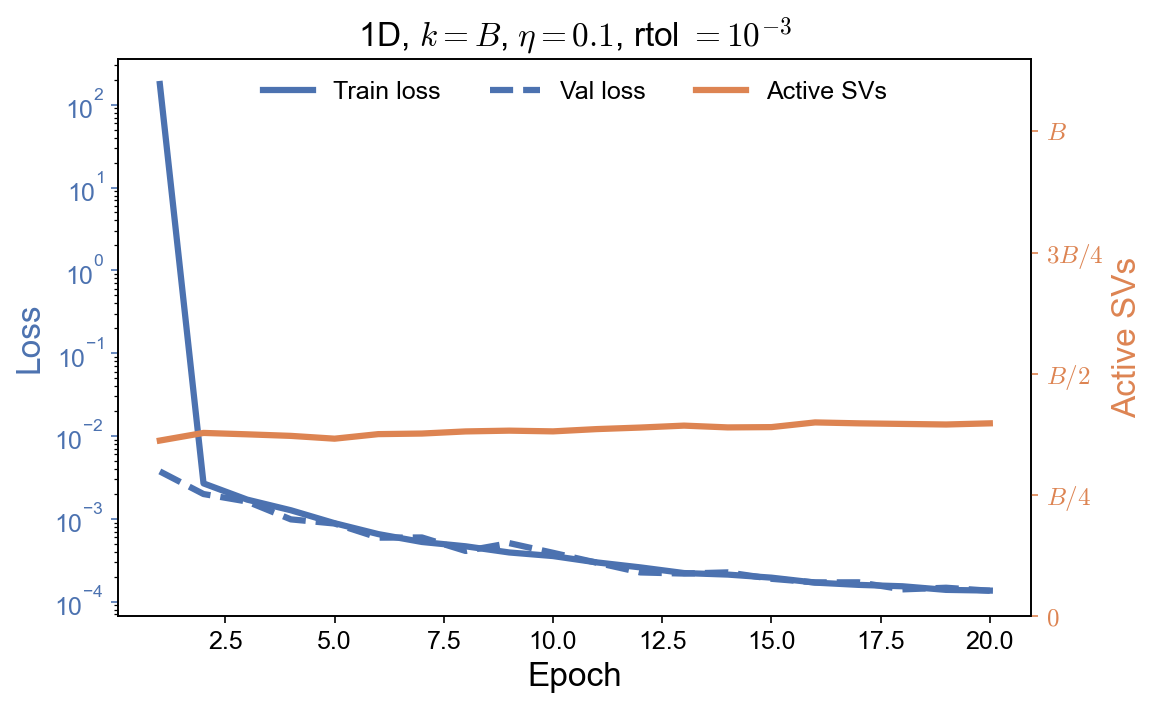

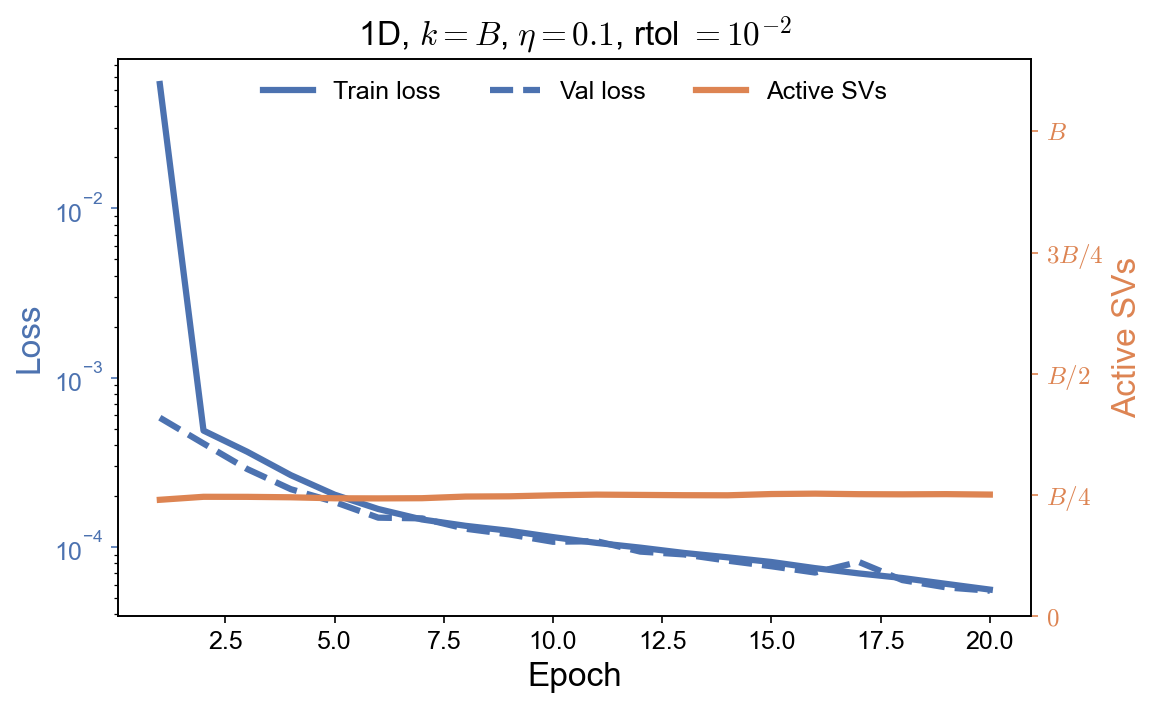

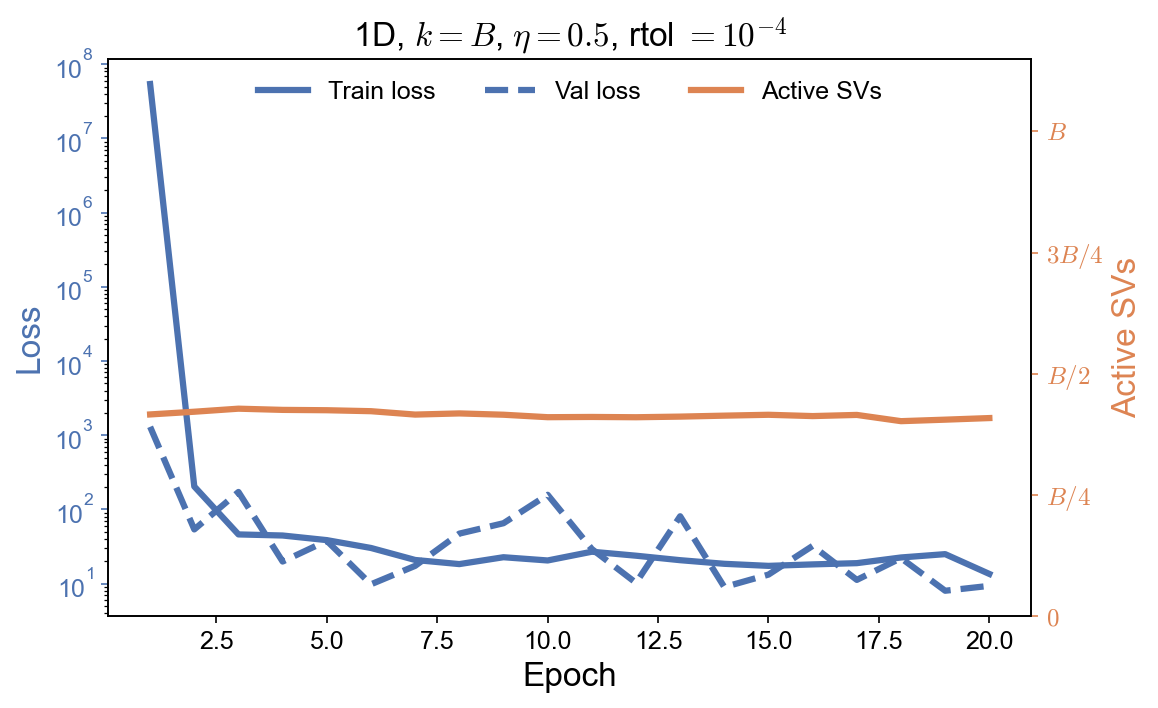

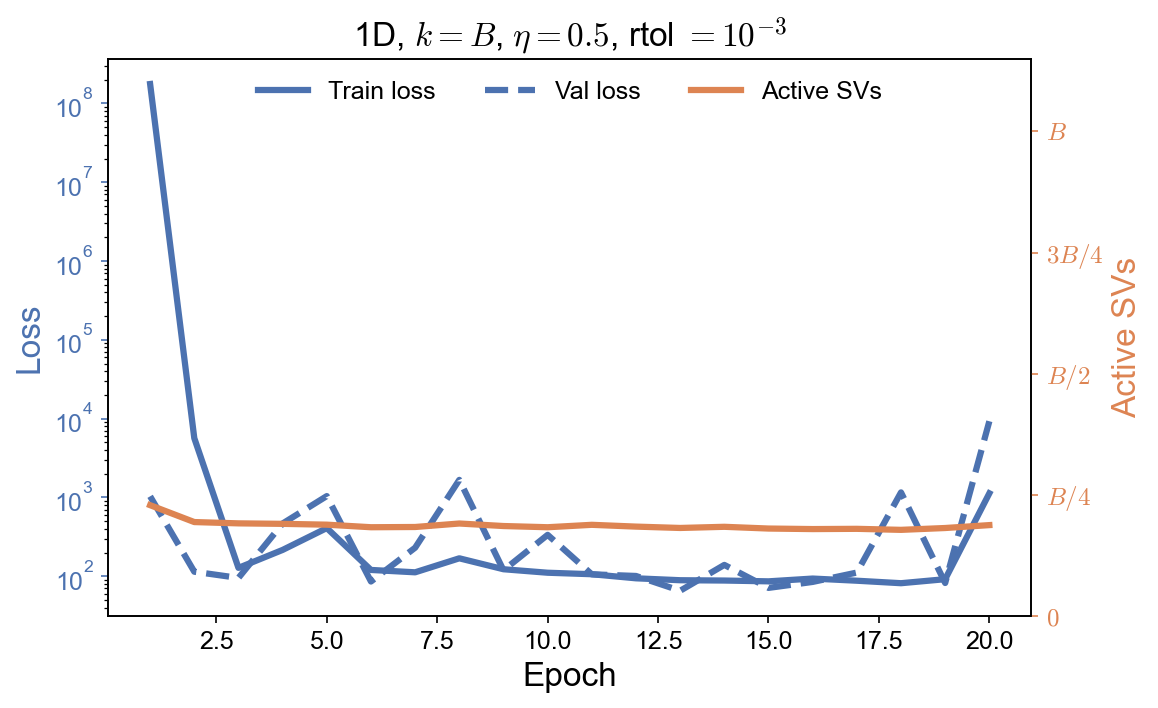

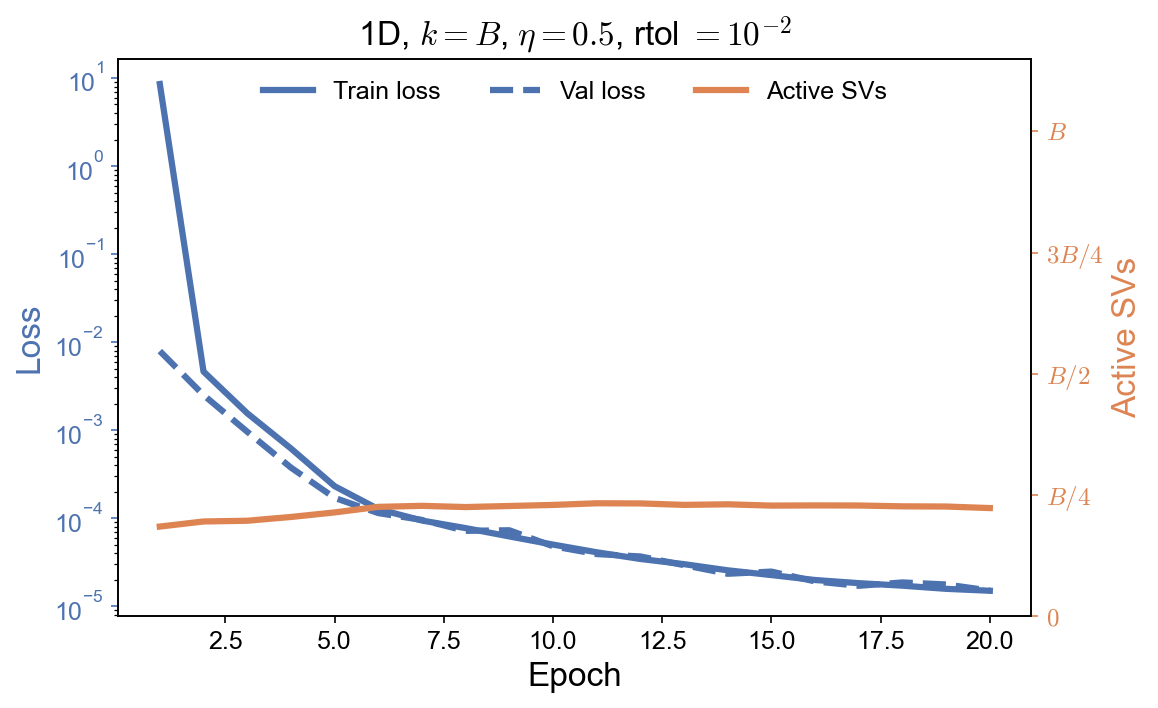

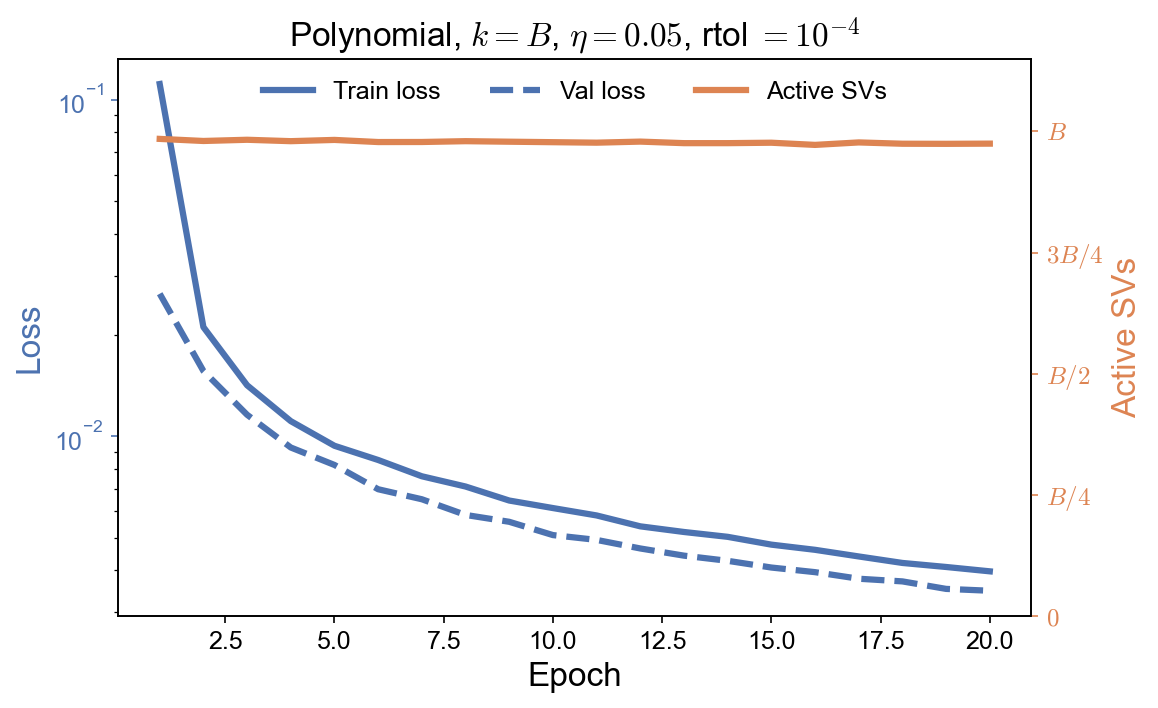

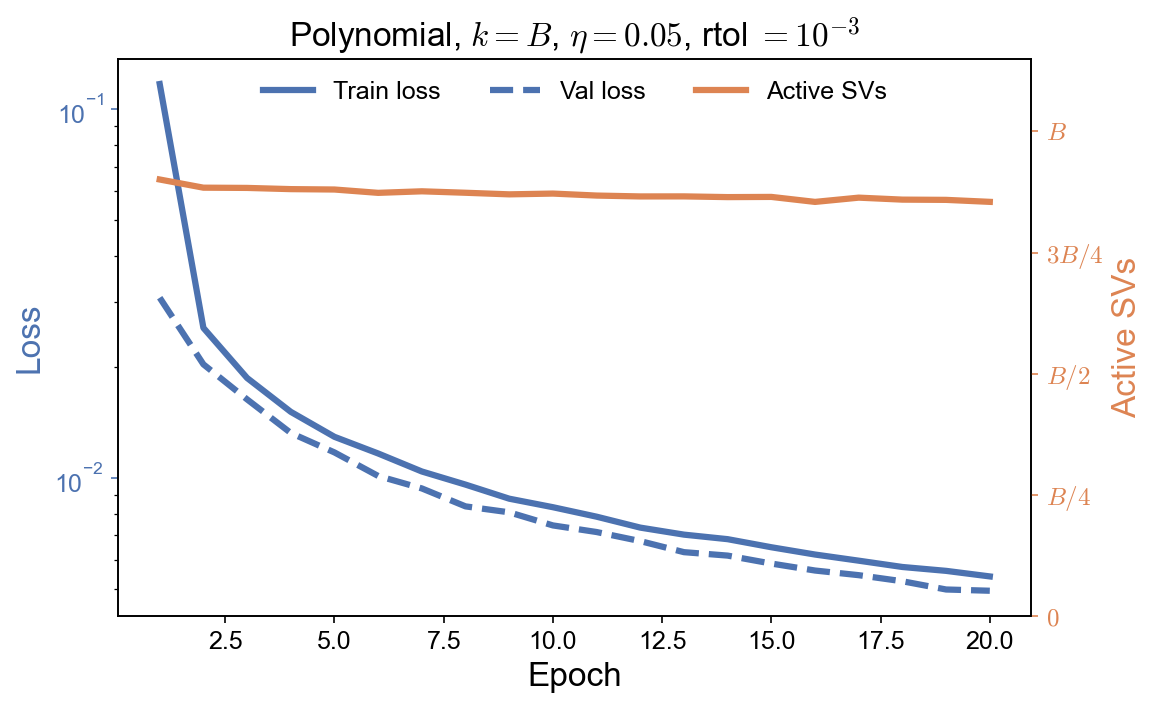

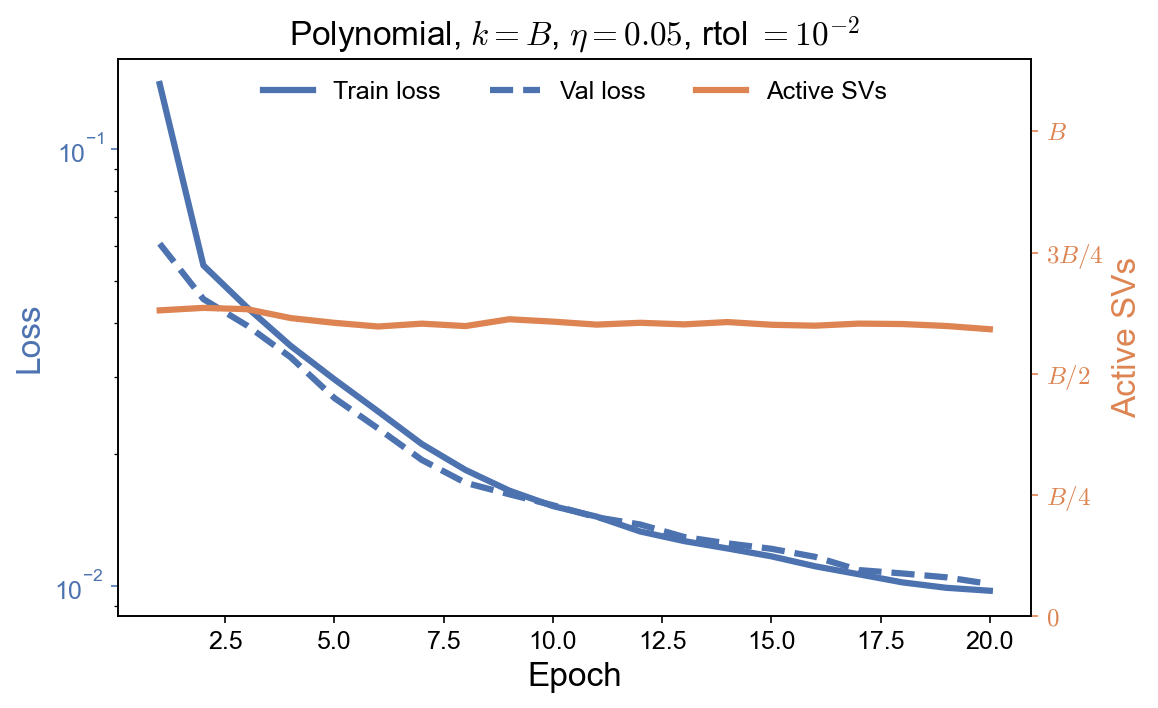

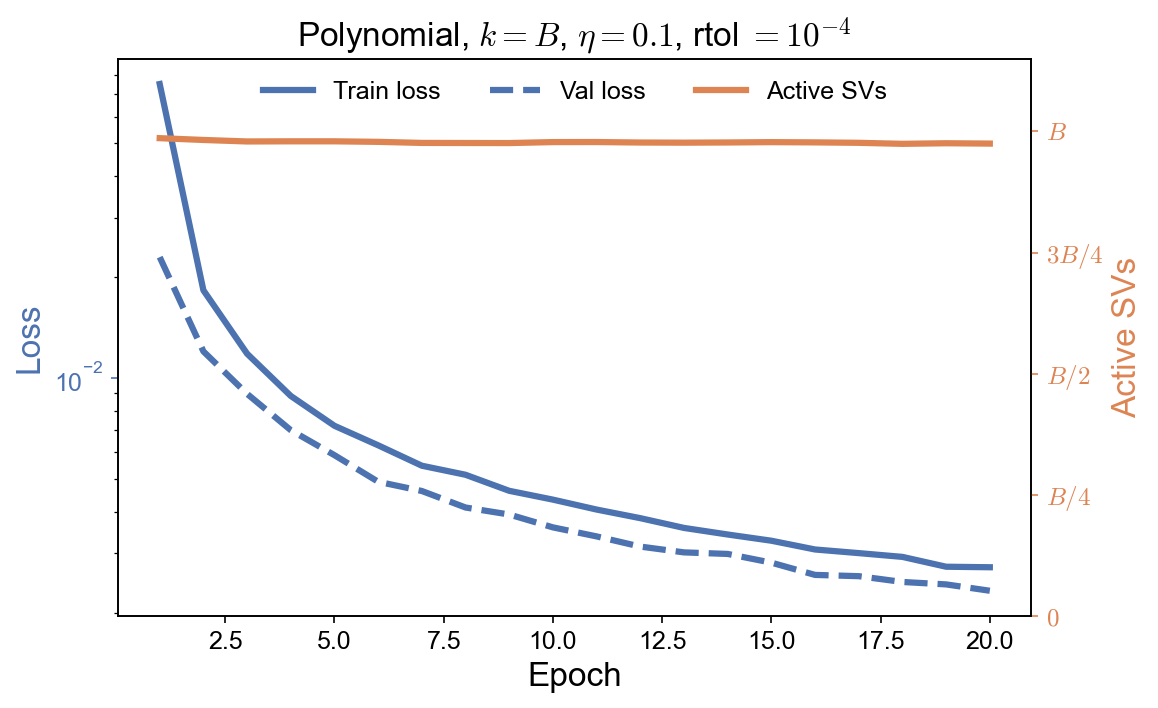

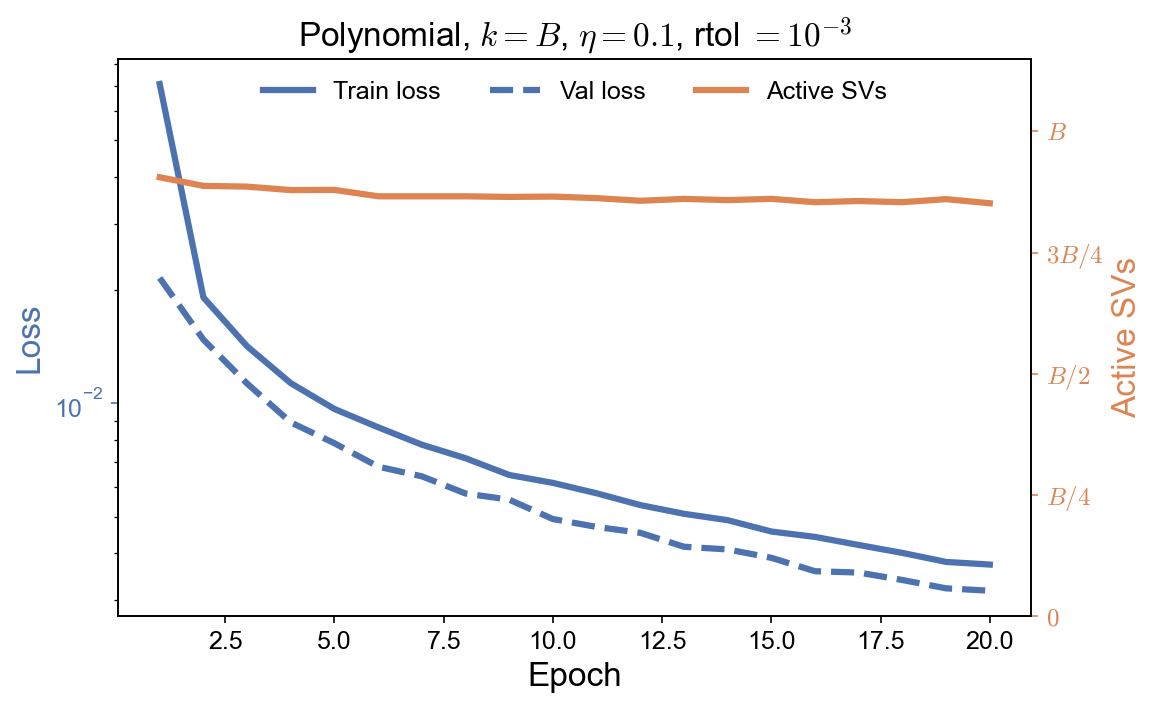

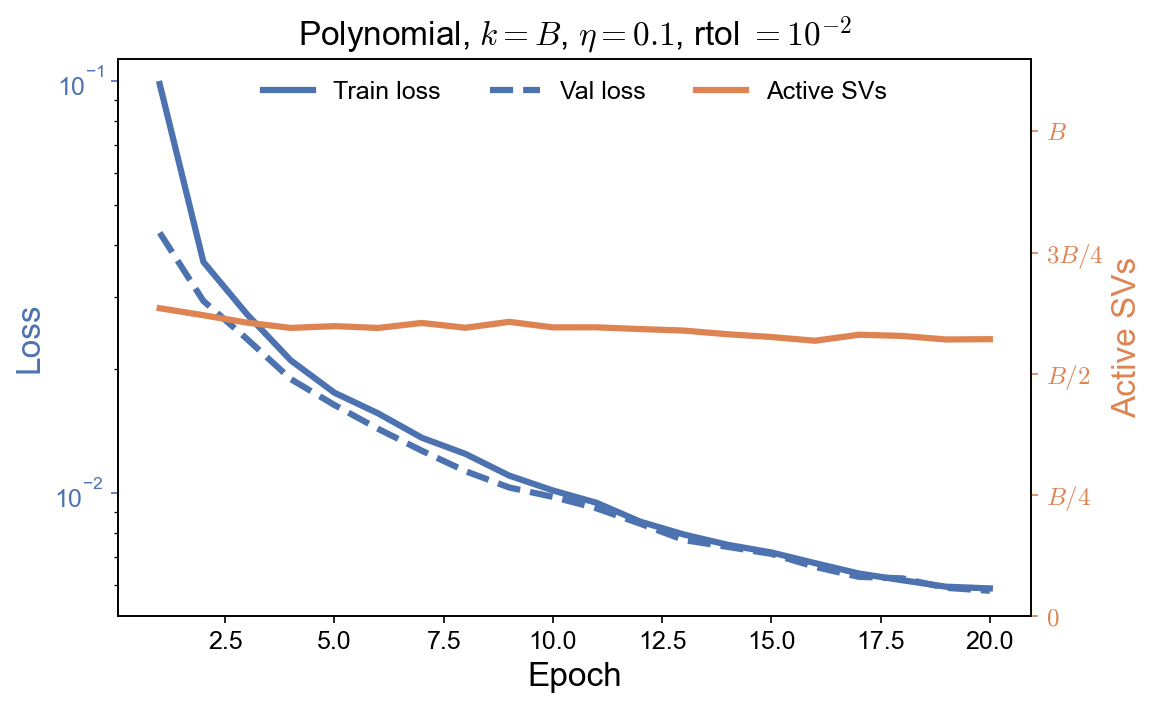

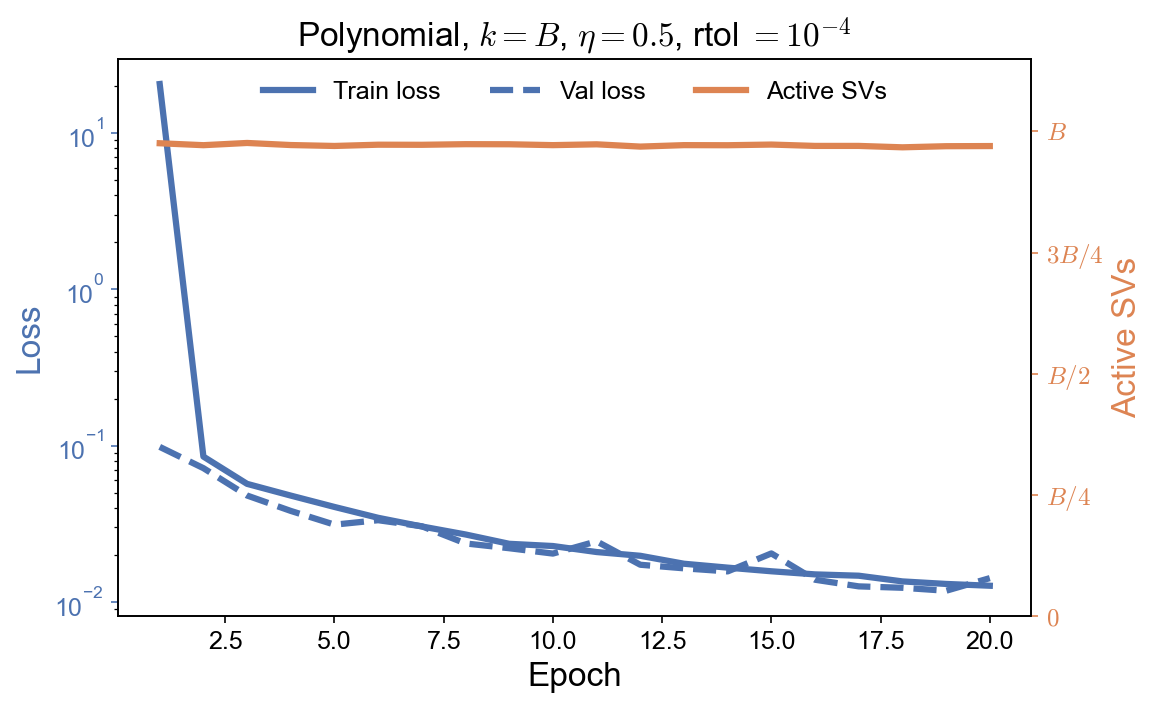

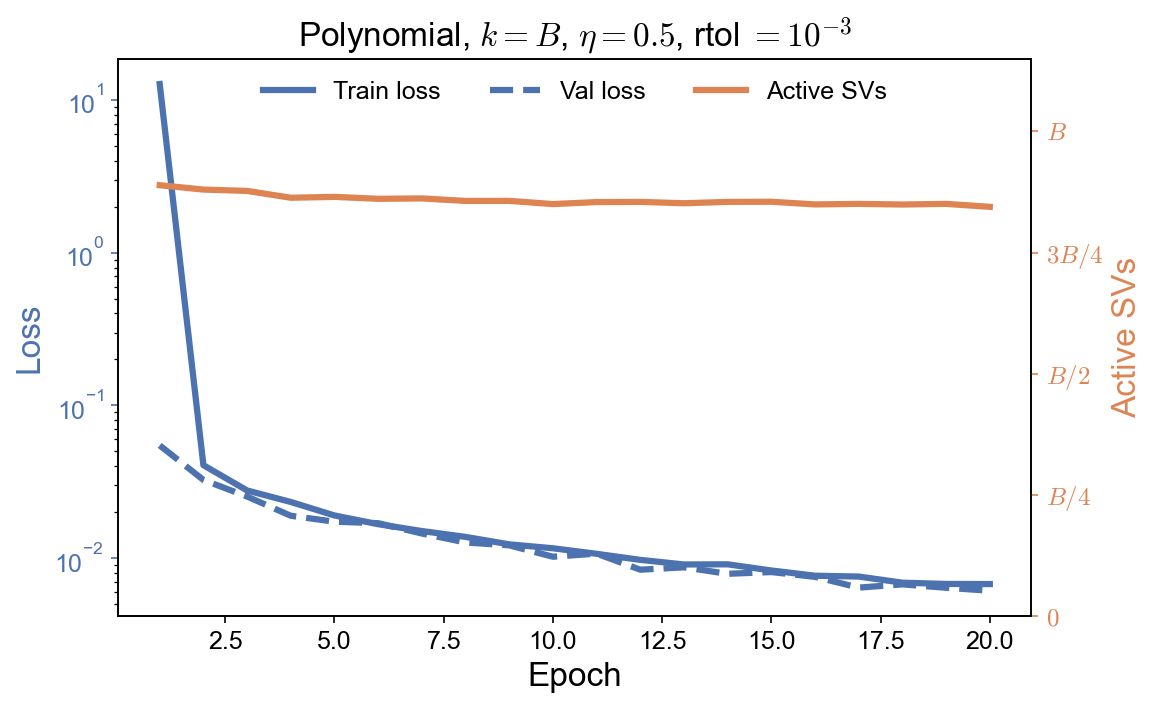

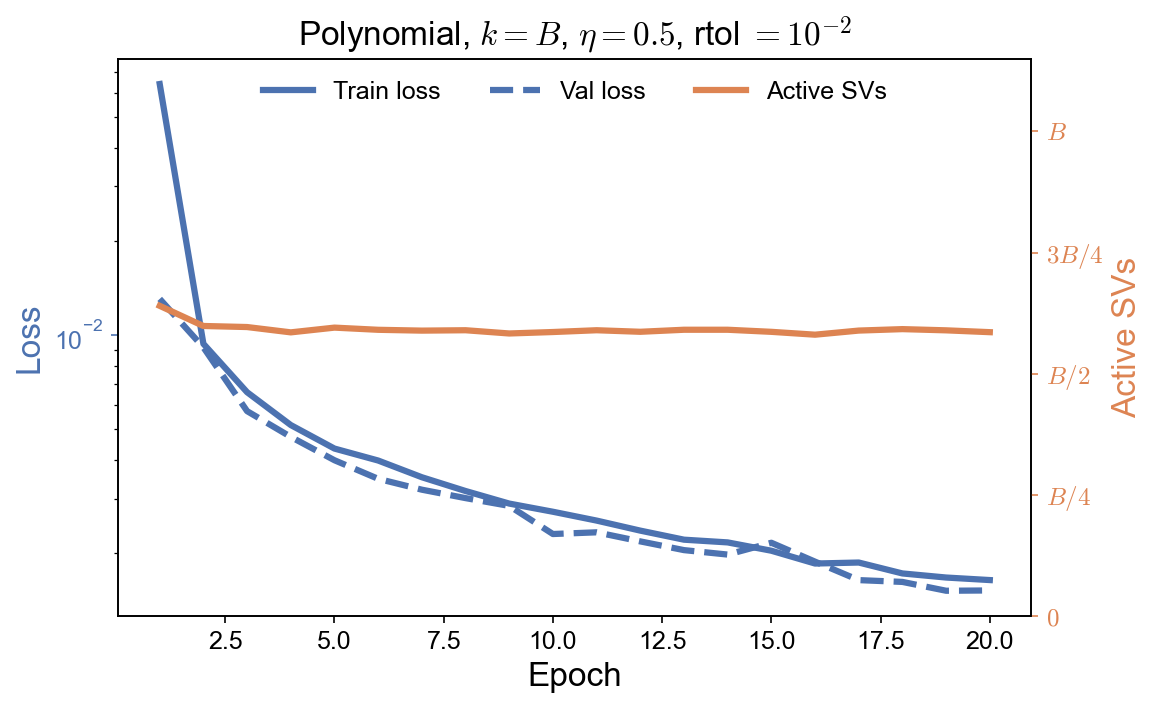

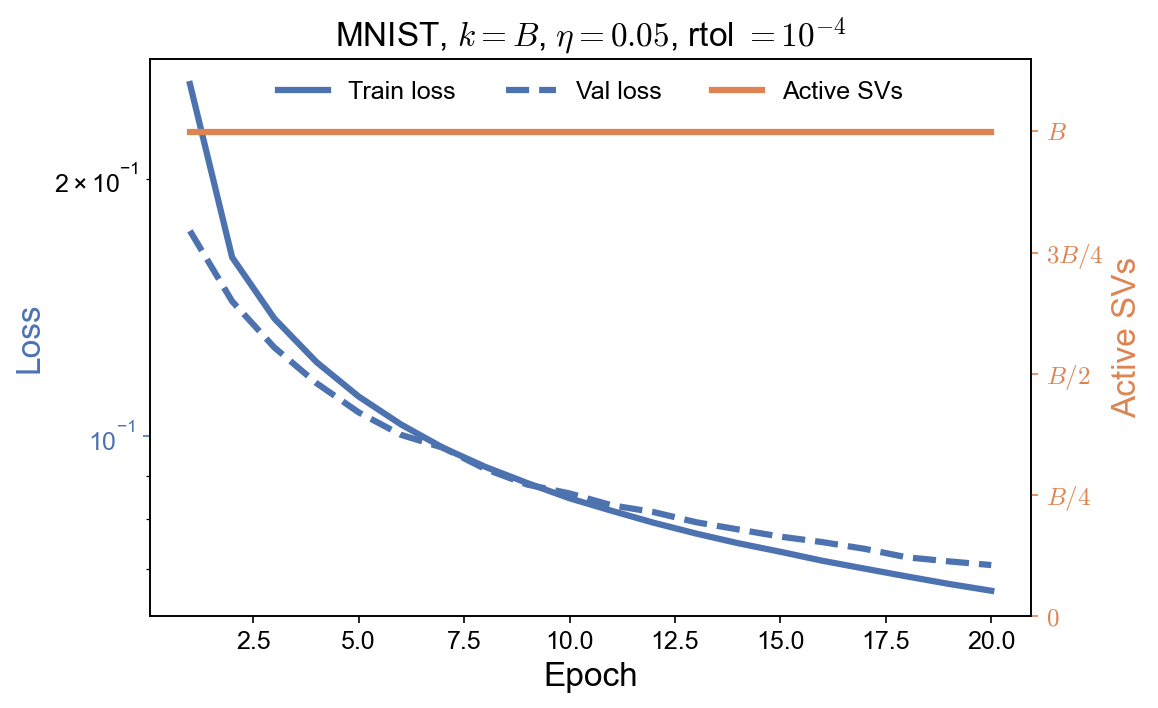

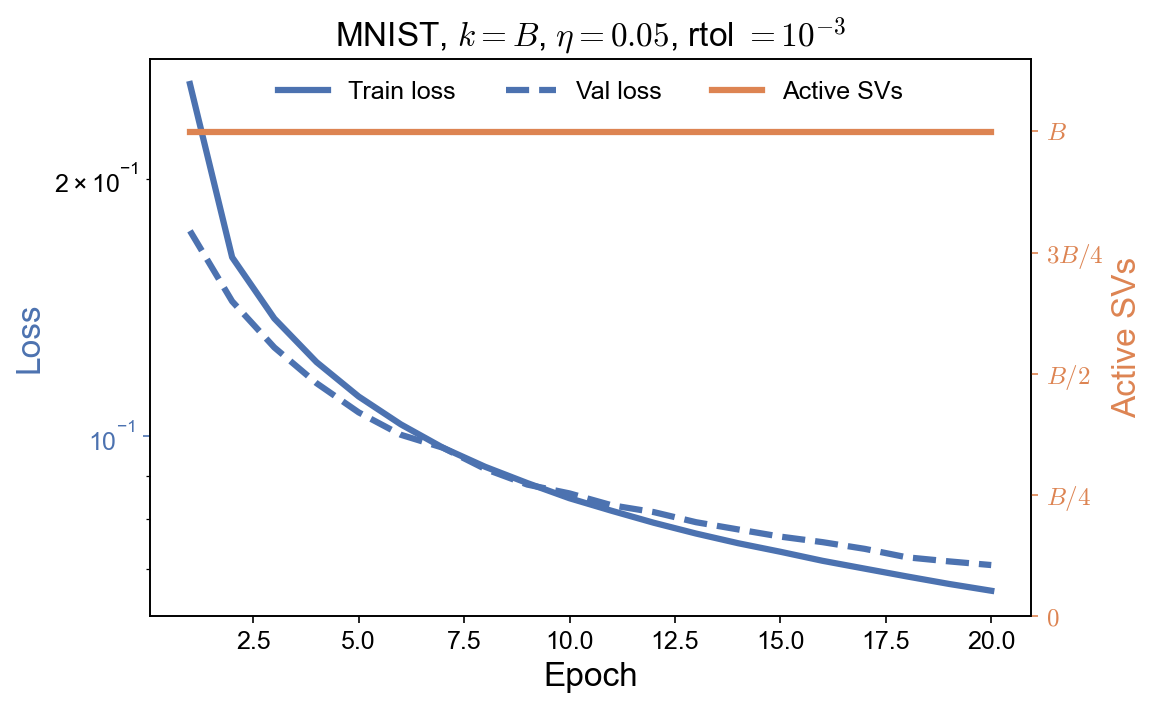

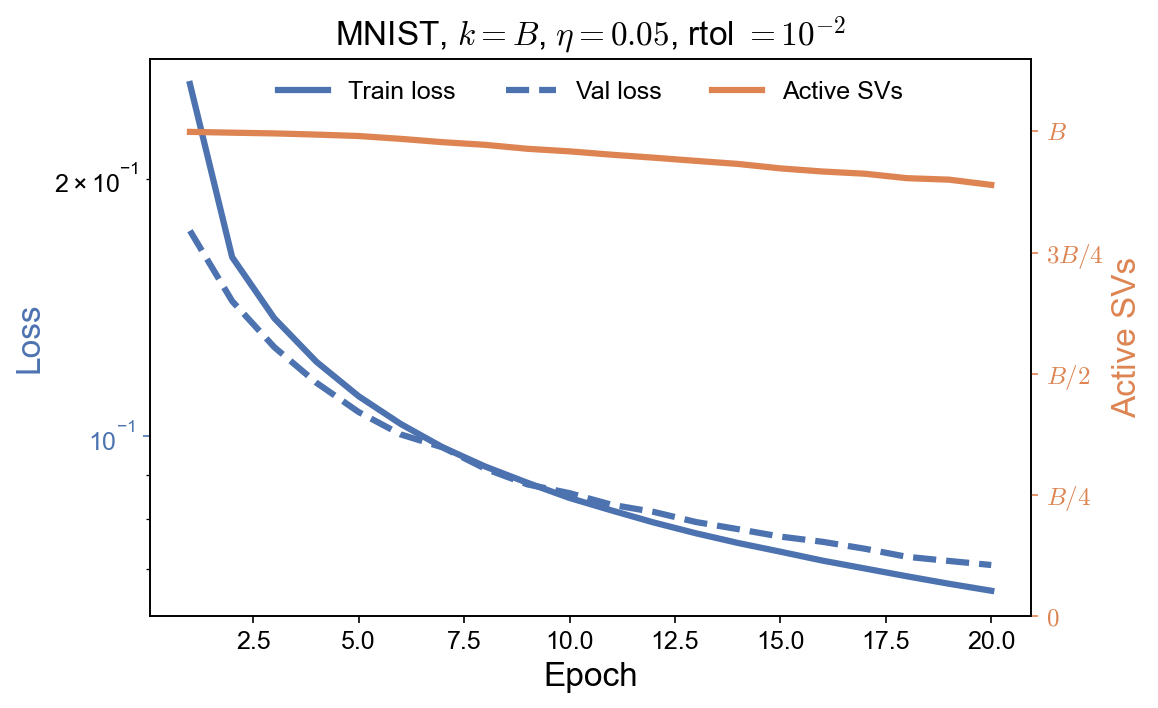

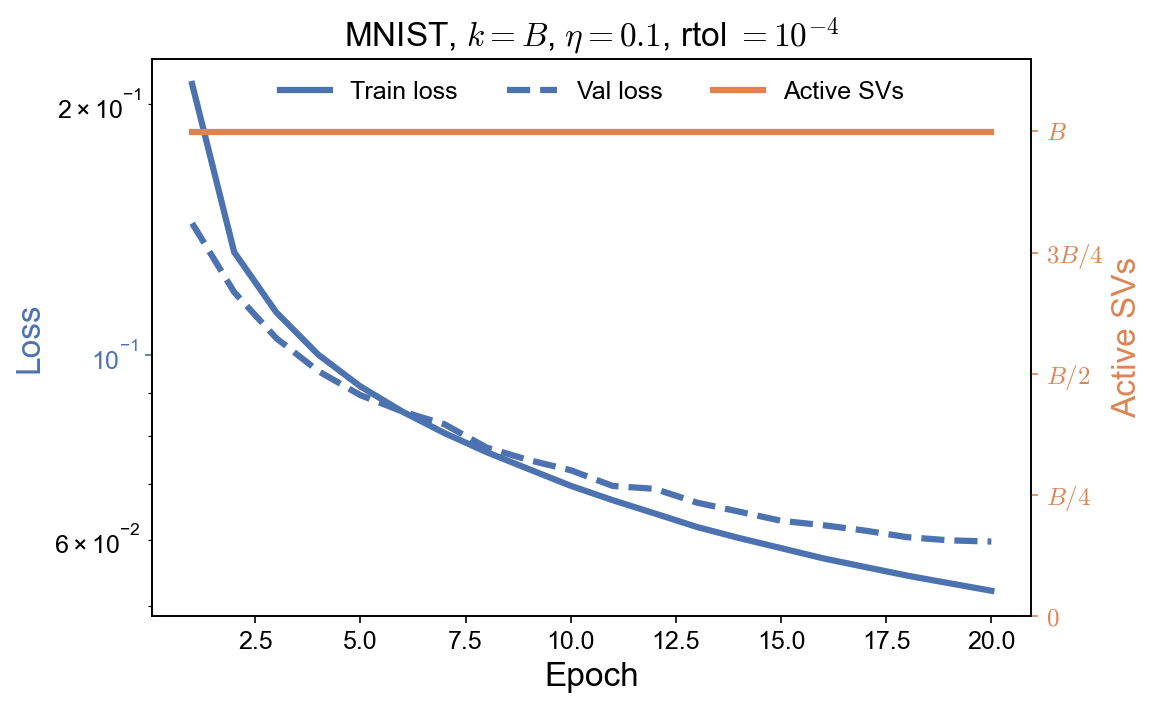

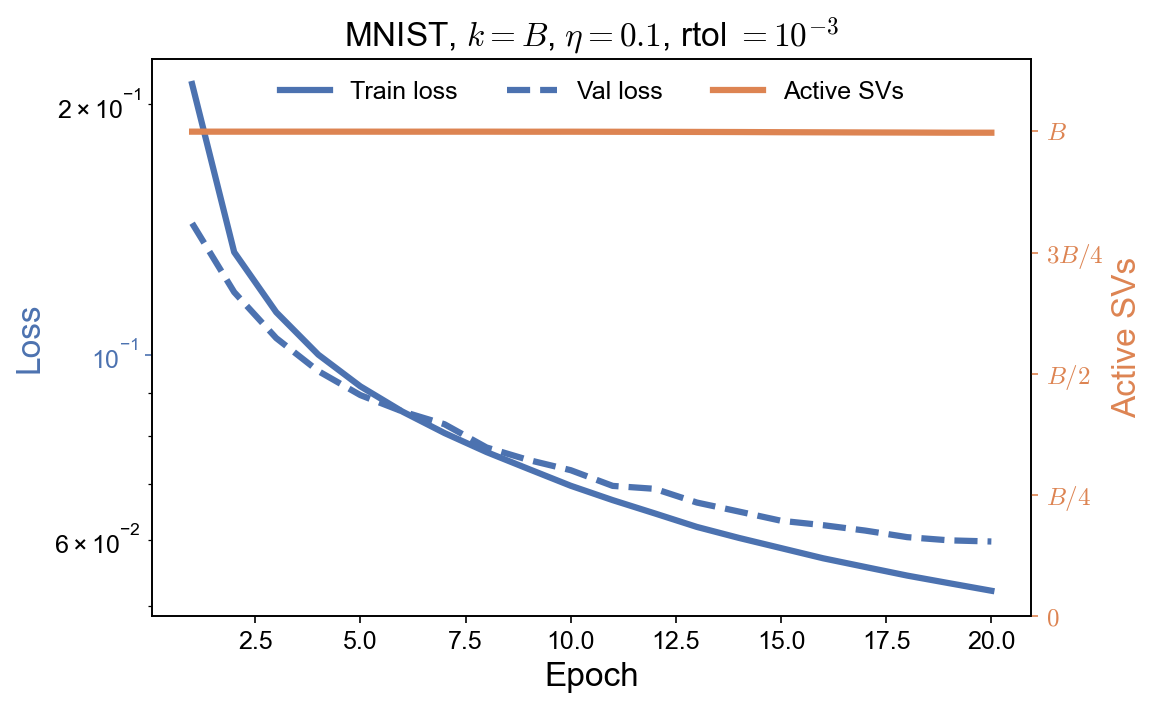

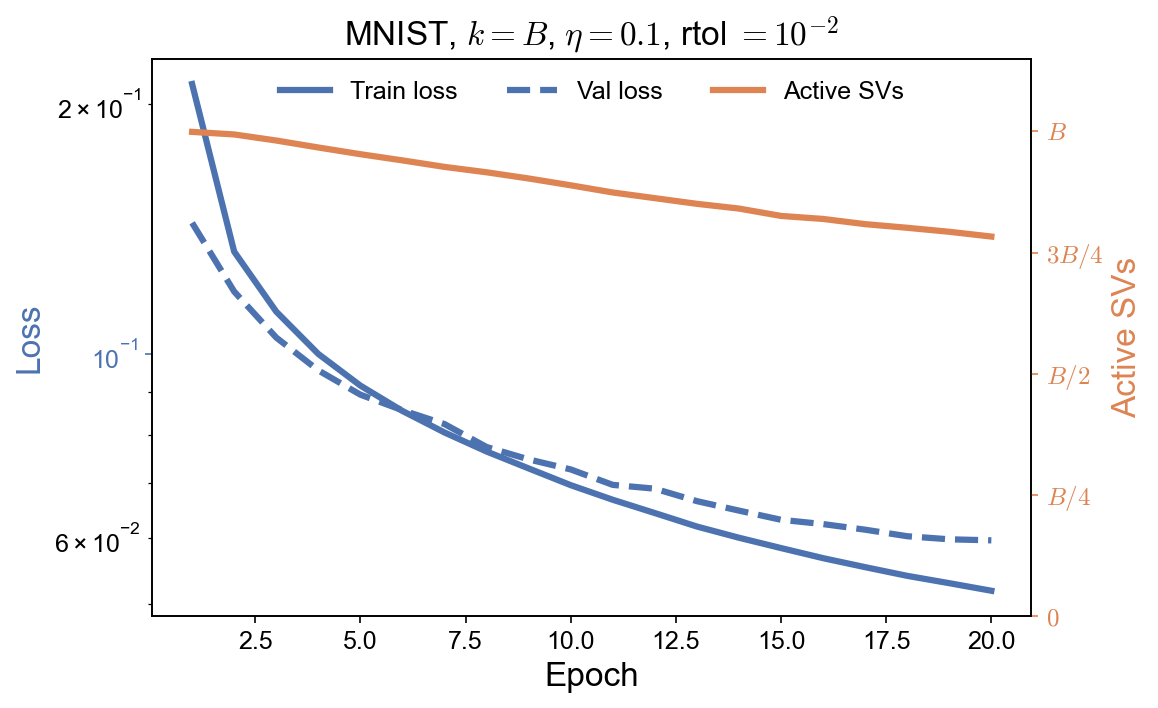

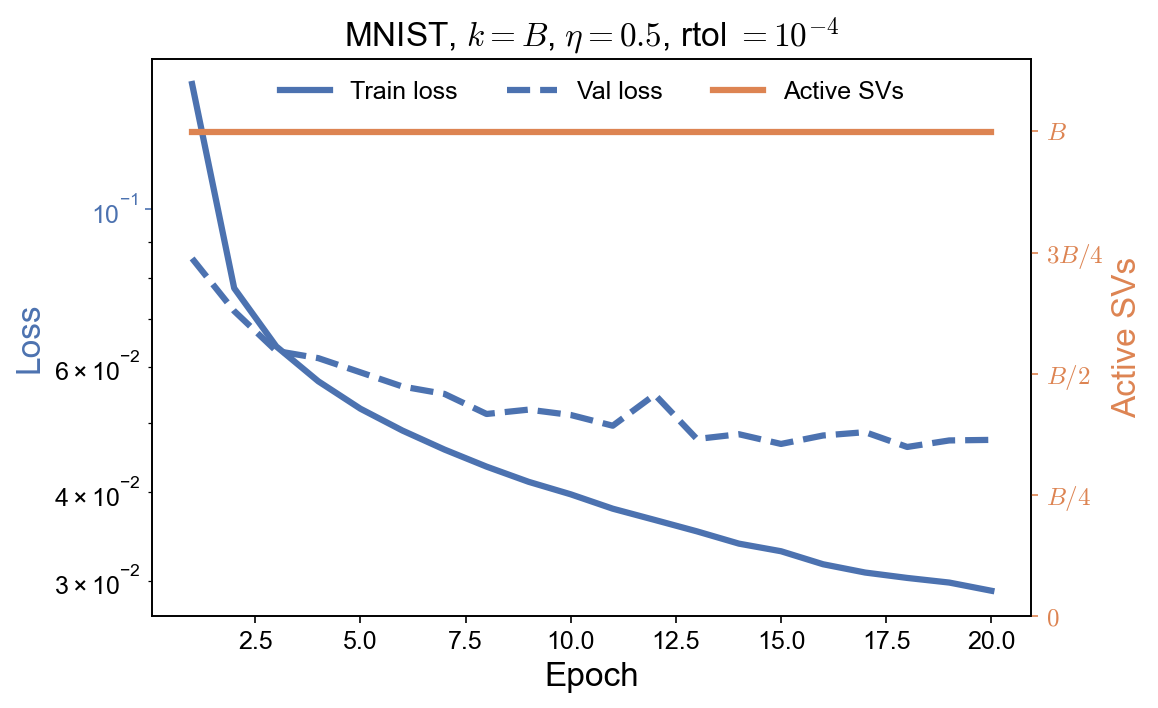

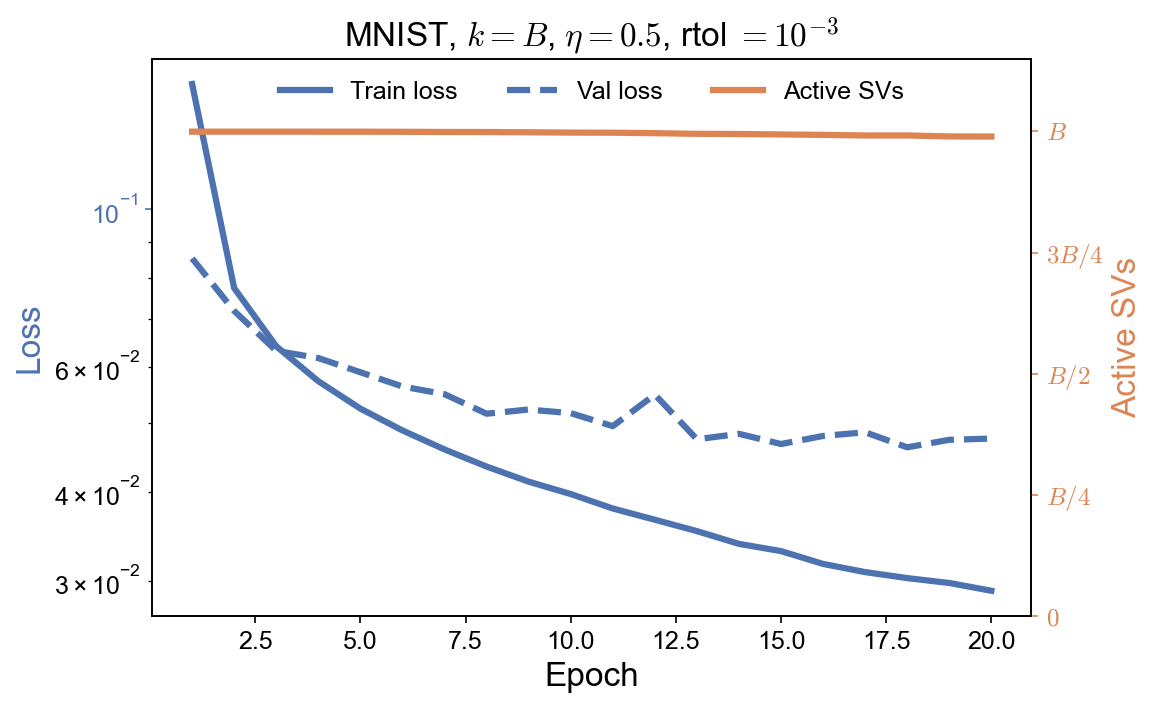

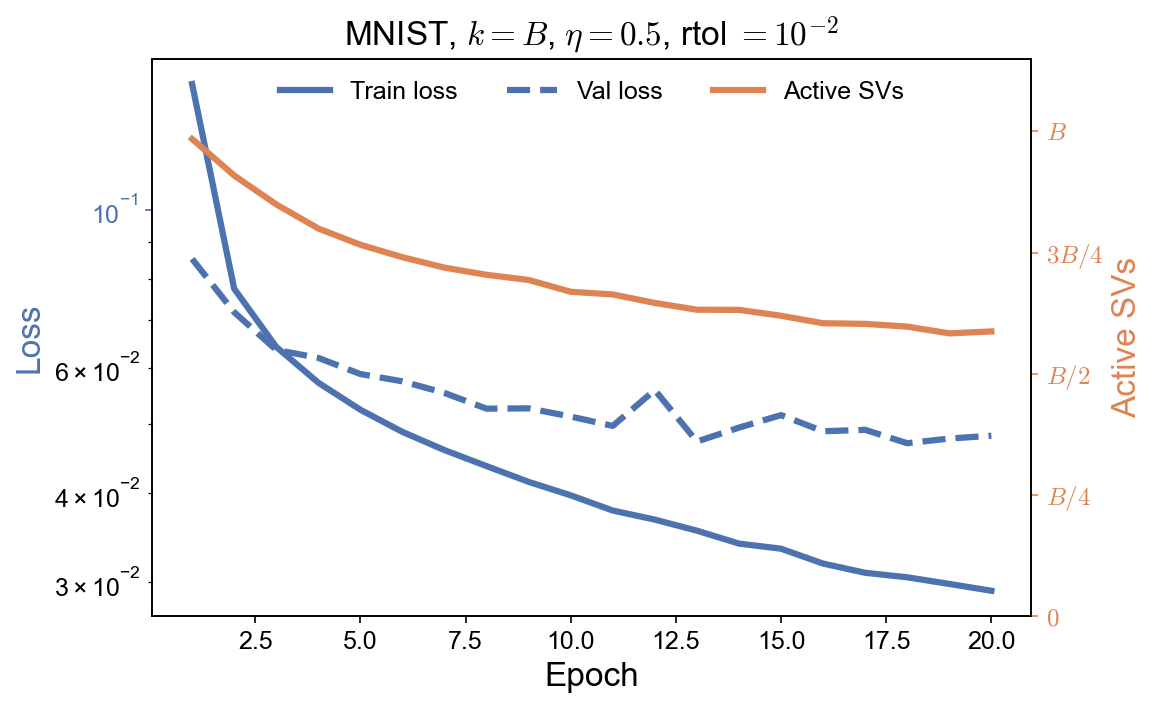

In [ ]:
RTOLS = [1e-4, 1e-3, 1e-2]
LRS = [0.05, 0.1, 0.5]

dfs     = [df_1d,  df_poly,      df_mnist]
bss     = [bs_1d,  bs_poly,      bs_mnist]
names   = ['1D',   'Polynomial', 'MNIST']
tags    = ['1d',   'poly',       'mnist']

loss_color = colors[0]
sv_color   = colors[1]

for df, bs, name, tag in zip(dfs, bss, names, tags):
    for lr in LRS:
        for rtol in RTOLS:
            sel = df[(df['rtol'] == rtol) & (df['lr'] == lr) & (df['k'] == bs)]
            if len(sel) == 0:
                continue
            row = sel.iloc[0]

            train_loss = np.array(row['losses']['train'])
            val_loss   = np.array(row['losses']['val'])[1:]  # drop pre-training entry

            n_epoch    = len(train_loss)
            train_ep   = np.arange(1, n_epoch + 1)
            val_ep     = np.arange(1, len(val_loss) + 1)

            svs        = np.array(row['svd_info']['num_nonzero_svs'])
            b_per_ep   = len(svs) // n_epoch
            svs_ep     = svs[:n_epoch * b_per_ep].reshape(n_epoch, b_per_ep).mean(axis=1)
            svs_ep_norm = svs_ep / bs

            fig, ax1 = plt.subplots(figsize=(8, 5))
            ax2 = ax1.twinx()

            l1, = ax1.plot(train_ep, train_loss, color=loss_color, lw=3, linestyle='-',  label='Train loss')
            l2, = ax1.plot(val_ep,   val_loss,   color=loss_color, lw=3, linestyle='--', label='Val loss')
            l3, = ax2.plot(train_ep, svs_ep_norm, color=sv_color,  lw=3, linestyle='-',  label='Active SVs')

            ax1.set_yscale('log')
            ax1.set_xlabel('Epoch')
            ax1.set_ylabel('Loss', color=loss_color)
            ax1.tick_params(axis='y', colors=loss_color)
            ax2.set_ylabel('Active SVs', color=sv_color)
            ax2.tick_params(axis='y', colors=sv_color)
            ax2.set_ylim(0, 1.15)
            ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0],
                           labels=['$0$', '$B/4$', '$B/2$', '$3B/4$', '$B$'])

            rtol_str = lr_labels.get(rtol, str(rtol))
            ax1.set_title(f'{name}, $k = B$, $\\eta = {lr}$, rtol $= {rtol_str}$')

            ax1.legend(handles=[l1, l2, l3], loc='upper center', frameon=False, ncol=3)

            plt.tight_layout()
            fname = PLOT_DIR / f'dual_axis_{tag}_lr{lr}_rtol{rtol:.0e}.pdf'
            fig.savefig(fname)
            plt.show()
            plt.close(fig)


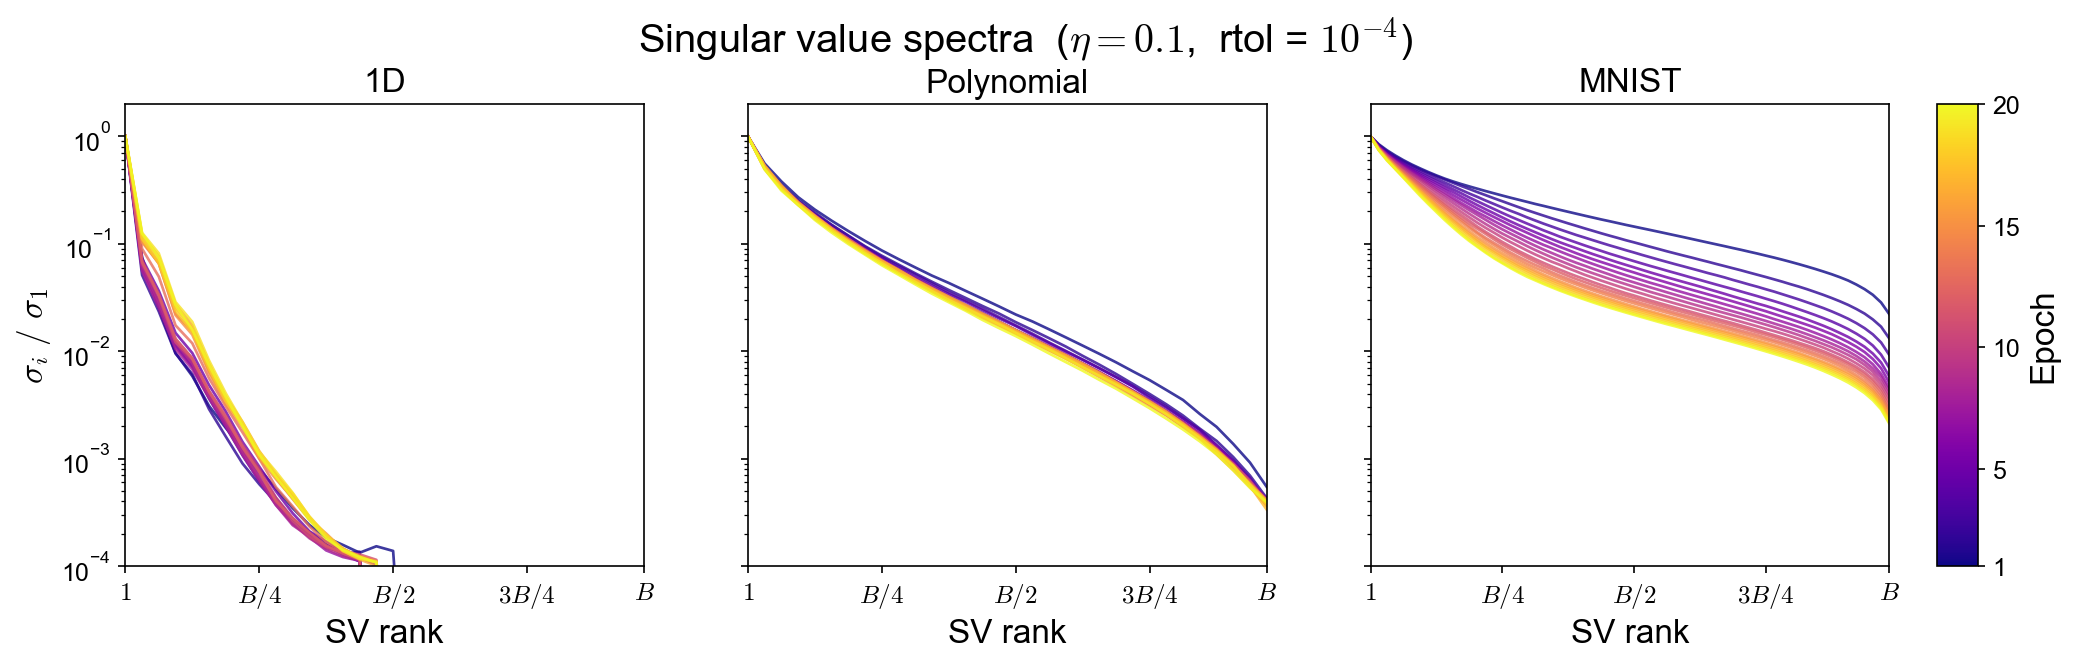

In [88]:

import matplotlib.cm as cm
import matplotlib.colors as mcolors

LR_VIZ    = 0.1
EPS_FLOOR = 1e-6

def get_epoch_spectra(df, bs, lr=LR_VIZ, rtol=1e-4):
    """Returns (raw spectra, σ_i/σ_1 normalized), shape (n_epoch, k)."""
    sel = df[(df['rtol'] == rtol) & (df['lr'] == lr) & (df['k'] == bs)]
    if len(sel) == 0:
        return None, None
    row      = sel.iloc[0]
    svs_raw  = row['svd_info']['svs']
    n_epoch  = len(row['losses']['train'])
    b_per_ep = len(svs_raw) // n_epoch
    k        = int(bs)
    spectra  = np.zeros((n_epoch, k))
    spectra_norm = np.zeros((n_epoch, k))
    for ep in range(n_epoch):
        #arr = np.zeros((b_per_ep, k))
        arr = np.zeros(k)
        arr_norms = np.zeros(k)
        denoms = np.zeros(k)
        for i, sv in enumerate(svs_raw[ep * b_per_ep:(ep + 1) * b_per_ep]):
            arr[:len(sv)] += sv
            arr_norms[:len(sv)] += np.array(sv) / sv[0]
            denoms[:len(sv)] += 1
        arr /= np.maximum(denoms, 1)  # avoid division by zero
        arr_norms /= np.maximum(denoms, 1)
        #for i, sv in enumerate(svs_raw[ep * b_per_ep:(ep + 1) * b_per_ep]):
        #    arr[i, :len(sv)] = sv
        #spectra[ep] = arr.mean(axis=0)
        #spectra[ep] = np.average(arr, axis=0, weights=(arr != 0).astype(float))
        spectra[ep] = arr
        spectra_norm[ep] = arr_norms
    return spectra, spectra_norm

# ── Plot 1: spectral decay lines, colored by training epoch ─────────
dfs_sv   = [df_1d,  df_poly,      df_mnist]
bss_sv   = [bs_1d,  bs_poly,      bs_mnist]
names_sv = ['1D',   'Polynomial', 'MNIST']

RTOLS_VIZ = [1e-2, 1e-3]
rtol_ls   = ['--', ':']

cmap_ep = plt.cm.plasma
N_EPOCH  = 20
norm_ep  = mcolors.Normalize(vmin=1, vmax=N_EPOCH)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, df, bs, name in zip(axes, dfs_sv, bss_sv, names_sv):
    _, spec_norm = get_epoch_spectra(df, bs)
    n_ep, k      = spec_norm.shape

    for ep in range(n_ep):
        sv = np.clip(spec_norm[ep], EPS_FLOOR, 1.0)
        ax.semilogy(np.arange(k), sv,
                    color=cmap_ep(norm_ep(ep + 1)), lw=1.3, alpha=0.8)

    ax.set_xlabel('SV rank')
    ax.set_xlim(0, k - 1)
    ax.set_xticks([0, k//4, k//2, 3*k//4, k-1], labels=[f"$1$", f"$B/4$", f"$B/2$", f"$3B/4$", f"$B$"])
    ax.set_ylim(1e-4,None)
    ax.set_title(name)

axes[0].set_ylabel('$\\sigma_i \\ / \\ \\sigma_1$')

fig.subplots_adjust(right=0.86)
fig.canvas.draw()
pos  = axes[-1].get_position()
cax  = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.017, pos.height])
sm   = cm.ScalarMappable(cmap=cmap_ep, norm=norm_ep)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Epoch')
cbar.set_ticks([1, 5, 10, 15, 20])
plt.suptitle('Singular value spectra  ($\\eta = 0.1$,  rtol = $10^{-4}$)', y=1.03)

fig.savefig(PLOT_DIR / 'sv_spectra_lines.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)


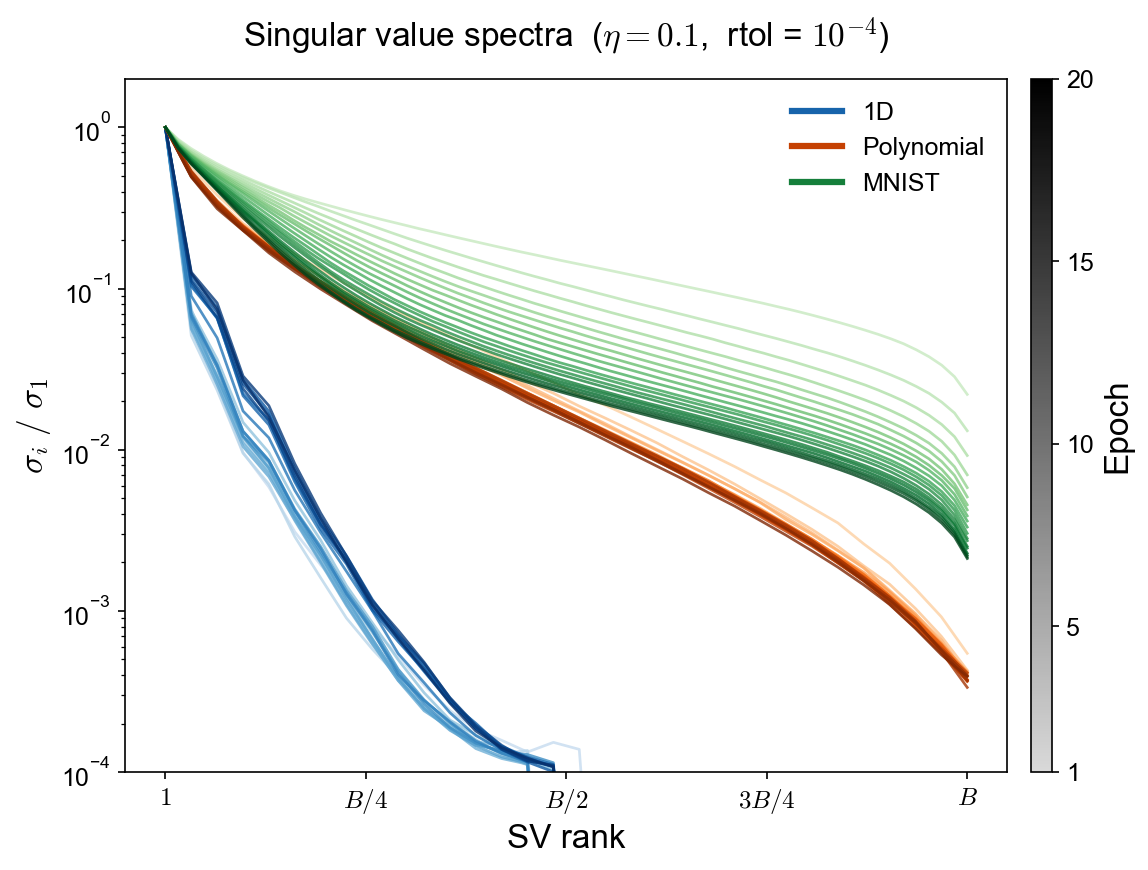

In [106]:

import matplotlib.cm as cm
import matplotlib.colors as mcolors

LR_VIZ    = 0.1
EPS_FLOOR = 1e-6

def get_epoch_spectra(df, bs, lr=LR_VIZ, rtol=1e-4):
    """Returns (raw spectra, σ_i/σ_1 normalized), shape (n_epoch, k)."""
    sel = df[(df['rtol'] == rtol) & (df['lr'] == lr) & (df['k'] == bs)]
    if len(sel) == 0:
        return None, None
    row      = sel.iloc[0]
    svs_raw  = row['svd_info']['svs']
    n_epoch  = len(row['losses']['train'])
    b_per_ep = len(svs_raw) // n_epoch
    k        = int(bs)
    spectra  = np.zeros((n_epoch, k))
    spectra_norm = np.zeros((n_epoch, k))
    for ep in range(n_epoch):
        #arr = np.zeros((b_per_ep, k))
        arr = np.zeros(k)
        arr_norms = np.zeros(k)
        denoms = np.zeros(k)
        for i, sv in enumerate(svs_raw[ep * b_per_ep:(ep + 1) * b_per_ep]):
            arr[:len(sv)] += sv
            arr_norms[:len(sv)] += np.array(sv) / sv[0]
            denoms[:len(sv)] += 1
        arr /= np.maximum(denoms, 1)  # avoid division by zero
        arr_norms /= np.maximum(denoms, 1)
        #for i, sv in enumerate(svs_raw[ep * b_per_ep:(ep + 1) * b_per_ep]):
        #    arr[i, :len(sv)] = sv
        #spectra[ep] = arr.mean(axis=0)
        #spectra[ep] = np.average(arr, axis=0, weights=(arr != 0).astype(float))
        spectra[ep] = arr
        spectra_norm[ep] = arr_norms
    return spectra, spectra_norm

# ── Plot 1: spectral decay lines, colored by training epoch ─────────
dfs_sv   = [df_1d,  df_poly,      df_mnist]
bss_sv   = [bs_1d,  bs_poly,      bs_mnist]
names_sv = ['1D',   'Polynomial', 'MNIST']

RTOLS_VIZ = [1e-2, 1e-3]
rtol_ls   = ['--', ':']

cmap_ep = plt.cm.plasma
N_EPOCH  = 20
def norm_ep(ep,lo=0.25,hi=1.0):
    norm = mcolors.Normalize(vmin=1, vmax=N_EPOCH)
    return lo + (hi - lo) * norm(ep)
#norm_ep  = mcolors.Normalize(vmin=1, vmax=N_EPOCH)

fig, ax = plt.subplots(1,1,figsize=(8,6))
cmaps = [cm.Blues, cm.Oranges, cm.Greens]

for df, bs, name, cmap in zip(dfs_sv, bss_sv, names_sv, cmaps):
    _, spec_norm = get_epoch_spectra(df, bs)
    n_ep, k      = spec_norm.shape

    for ep in range(n_ep):
        sv = np.clip(spec_norm[ep], EPS_FLOOR, 1.0)
        ax.semilogy(np.linspace(0,1,k), sv,
                    color=cmap(norm_ep(ep + 1)), lw=1.3, alpha=0.8)

    ax.set_xlabel('SV rank')
    ax.set_xticks([0, 1/4, 1/2, 3/4, 1], labels=[f"$1$", f"$B/4$", f"$B/2$", f"$3B/4$", f"$B$"])
    ax.set_ylim(1e-4,None)

ax.set_ylabel('$\\sigma_i \\ / \\ \\sigma_1$')
legend_entries = [
    Line2D([],[],color=cmap(0.8),label=name, lw=3) for name, cmap in zip(names_sv, cmaps)
]
ax.legend(handles=legend_entries, loc='upper right', frameon=False)

fig.subplots_adjust(right=0.86)
fig.canvas.draw()
pos  = ax.get_position()
cax  = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.017, pos.height])

gray_clipped = mcolors.LinearSegmentedColormap.from_list(
    'gray_clipped',
    [cm.Grays(0.25), cm.Grays(1.0)]
)
sm   = cm.ScalarMappable(cmap=gray_clipped, norm=mcolors.Normalize(vmin=1, vmax=N_EPOCH))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Epoch')
cbar.set_ticks([1, 5, 10, 15, 20])
ax.set_title('Singular value spectra  ($\\eta = 0.1$,  rtol = $10^{-4}$)', y=1.03)

fig.savefig(PLOT_DIR / 'sv_spectra_lines_combined.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)


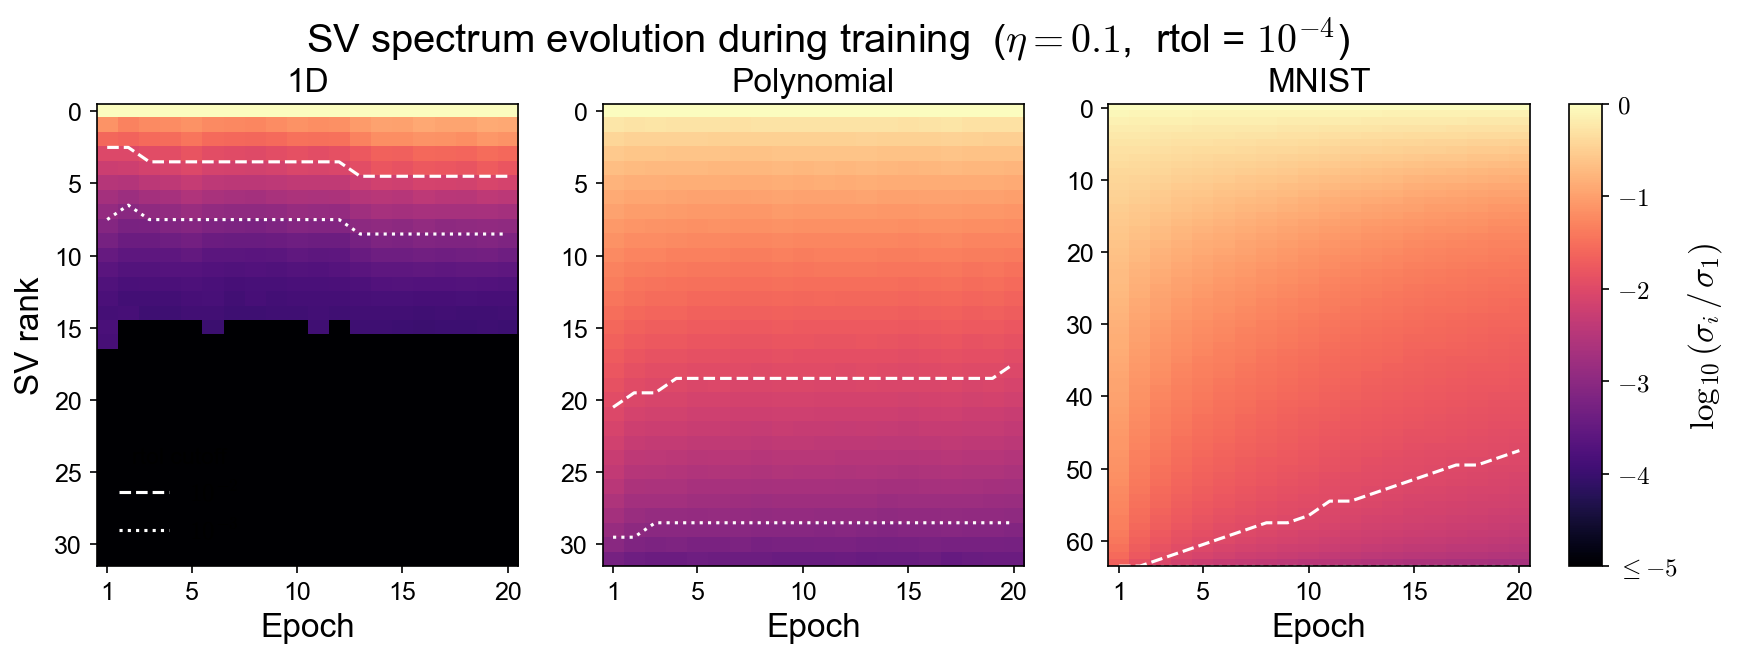

In [83]:
# ── Plot 2: 2-D heatmap — rank × epoch, log10(σ_i/σ_1) ─────────────
LOG_FLOOR = -5.0

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, df, bs, name in zip(axes, dfs_sv, bss_sv, names_sv):
    _, spec_norm = get_epoch_spectra(df, bs)
    n_ep, k      = spec_norm.shape
    log_spec     = np.log10(np.clip(spec_norm, 10**LOG_FLOOR, 1.0))

    im = ax.imshow(
        log_spec.T,
        aspect='auto', origin='upper',
        extent=[0.5, n_ep + 0.5, k - 0.5, -0.5],
        cmap='magma', vmin=LOG_FLOOR, vmax=0,
    )

    epoch_ax = np.arange(1, n_ep + 1)
    for rtol, ls in zip([1e-2, 1e-3], ['--', ':']):
        cutoff = np.array([np.sum(spec_norm[ep] >= rtol)
                           for ep in range(n_ep)], dtype=float) - 0.5
        ax.plot(epoch_ax, cutoff, color='white', lw=1.5, ls=ls,
                label=f'$10^{{{int(np.log10(rtol))}}}$')

    ax.set_xlabel('Epoch')
    ax.set_title(name)
    ax.set_xticks([1, 5, 10, 15, 20])

axes[0].set_ylabel('SV rank')
axes[0].legend(loc='lower left', frameon=False,
               title='rtol cutoff', title_fontsize=11)

fig.subplots_adjust(right=0.86)
fig.canvas.draw()
pos = axes[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.017, pos.height])
cb  = fig.colorbar(im, cax=cax)
cb.set_label('$\\log_{10}(\\sigma_i \\,/\\, \\sigma_1)$')
cb.set_ticks([0, -1, -2, -3, -4, -5])
cb.set_ticklabels(['$0$', '$-1$', '$-2$', '$-3$', '$-4$', '$\\leq{-5}$'])
plt.suptitle('SV spectrum evolution during training  ($\\eta = 0.1$,  rtol = $10^{-4}$)', y=1.03)
#plt.tight_layout()

fig.savefig(PLOT_DIR / 'sv_heatmap.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)
